# TFM 7.- HERRAMIENTA INTERACTIVA

     m o-o l o-a l o
     molopezalonso@gmail.com
     Mónica López Alonso

Primero hemos creado en la carpeta principal del TFM, una carpeta llamada `herramienta_interactiva`, donde hemos creado a su vez un archivo llamado `app.py`.

La estructura es la siguiente:

    TFM/
    │
    ├── data/
    ├── notebooks/
    │
    └── herramienta_interactiva/
        └── app.py

Luego abrimos **Anaconda Promt** y activamos el entorno que estamos utilizando:

In [ ]:
conda activate tfm_env
pip install streamlit
streamlit --version

Desde Anaconda Promt ejecutamos lo siguiente:

# 1. PÁGINA DE INICIO

---
# 2. PÁGINA DE COMPARACIÓN

## DIMENSIONES DE RIESGO PARA LA HERRAMIENTA INTERACTIVA

Este notebook desarrolla un sistema descriptivo de dimensiones de riesgo destinado a la comparación de países dentro de la herramienta interactiva.

El objetivo es resumir la información disponible en cinco grandes dimensiones:

1. Riesgo macroeconómico.
2. Riesgo fiscal.
3. Riesgo externo.
4. Riesgo institucional.
5. Riesgo político y de estabilidad.

Estas dimensiones no constituyen modelos predictivos ni sustituyen al Random Forest utilizado para estimar el rating soberano futuro. Su finalidad es exclusivamente descriptiva y permite comparar de forma sencilla el perfil relativo de distintos países.

Para hacer comparables variables expresadas en unidades diferentes, cada indicador se transforma anualmente a una escala de riesgo comprendida entre 0 y 100 utilizando su posición percentil respecto al resto de economías disponibles en ese mismo año.

La interpretación será:

$$
0 = \text{menor vulnerabilidad relativa}
$$

$$
100 = \text{mayor vulnerabilidad relativa}
$$

Cuando valores elevados de una variable representan una situación favorable, el percentil se invierte. Posteriormente, cada dimensión se obtiene mediante la media simple de los indicadores que la componen.

El uso de pesos iguales evita introducir ponderaciones arbitrarias y mantiene las dimensiones como indicadores descriptivos independientes del modelo predictivo principal.

In [98]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option(
    "display.max_columns",
    None
)

MODEL_DATA_PATH = Path(
    "data/model"
)

INDICATORS_FILE = (
    MODEL_DATA_PATH
    / "country_risk_panel_integrated_raw_2000_2024.csv"
)

data = pd.read_csv(
    INDICATORS_FILE
)

print(
    "Observaciones:",
    len(data)
)

print(
    "Variables:",
    data.shape[1]
)

print(
    "Periodo:",
    data["year"].min(),
    "-",
    data["year"].max()
)

print(
    "Economías:",
    data["iso3"].nunique()
)

Observaciones: 5425
Variables: 71
Periodo: 2000 - 2024
Economías: 217


In [99]:
dimension_candidates = {
    
    "Macroeconómica": [
        "gdp_growth_pct",
        "gdp_per_capita_constant_2015_usd",
        "gdp_per_capita_ppp_constant_2021_intl_usd",
        "inflation_cpi_pct",
        "unemployment_pct",
        "investment_pct_gdp",
        "gross_savings_pct_gdp"
    ],

    "Fiscal": [
        "government_debt_pct_gdp",
        "fiscal_balance_pct_gdp",
        "primary_balance_pct_gdp",
        "government_revenue_pct_gdp",
        "government_expenditure_pct_gdp",
        "net_interest_payments_pct_gdp"
    ],

    "Externa": [
        "current_account_balance_pct_gdp",
        "reserves_months_imports",
        "exports_pct_gdp",
        "imports_pct_gdp",
        "fdi_net_inflows_pct_gdp"
    ],

    "Institucional": [
        "government_effectiveness_estimate",
        "regulatory_quality_estimate",
        "rule_of_law_estimate",
        "control_of_corruption_estimate",
        "voice_accountability_estimate"
    ],

    "Política y estabilidad": [
        "political_stability_estimate",
        "electoral_democracy_index",
        "armed_conflict_dummy"
    ],

    "Historial crediticio": [
        "years_since_last_default",
        "never_default_history_dummy",
        "default_previous_5y",
        "default_previous_10y",
        "sovereign_debt_in_default_usd_mn"
    ]
}

In [100]:
for dimension, variables in dimension_candidates.items():

    available = [
        variable
        for variable in variables
        if variable in data.columns
    ]

    missing = [
        variable
        for variable in variables
        if variable not in data.columns
    ]

    print(
        "\n",
        dimension
    )

    print(
        "Disponibles:",
        len(available)
    )

    print(
        available
    )

    if missing:

        print(
            "No encontradas:",
            missing
        )


 Macroeconómica
Disponibles: 7
['gdp_growth_pct', 'gdp_per_capita_constant_2015_usd', 'gdp_per_capita_ppp_constant_2021_intl_usd', 'inflation_cpi_pct', 'unemployment_pct', 'investment_pct_gdp', 'gross_savings_pct_gdp']

 Fiscal
Disponibles: 6
['government_debt_pct_gdp', 'fiscal_balance_pct_gdp', 'primary_balance_pct_gdp', 'government_revenue_pct_gdp', 'government_expenditure_pct_gdp', 'net_interest_payments_pct_gdp']

 Externa
Disponibles: 5
['current_account_balance_pct_gdp', 'reserves_months_imports', 'exports_pct_gdp', 'imports_pct_gdp', 'fdi_net_inflows_pct_gdp']

 Institucional
Disponibles: 5
['government_effectiveness_estimate', 'regulatory_quality_estimate', 'rule_of_law_estimate', 'control_of_corruption_estimate', 'voice_accountability_estimate']

 Política y estabilidad
Disponibles: 3
['political_stability_estimate', 'electoral_democracy_index', 'armed_conflict_dummy']

 Historial crediticio
Disponibles: 5
['years_since_last_default', 'never_default_history_dummy', 'default_p

## Definición de las dimensiones de riesgo

A partir del conjunto inicial de variables se seleccionan aquellos indicadores que presentan una interpretación económica suficientemente clara en términos de vulnerabilidad.

Se excluyen algunas variables cuyo nivel no puede asociarse de forma inequívoca con un mayor o menor riesgo. Por ejemplo, unos ingresos o gastos públicos elevados no implican necesariamente una situación fiscal más vulnerable, mientras que el peso de las exportaciones o importaciones sobre el PIB puede estar relacionado con características estructurales de apertura y tamaño económico.

Asimismo, se evita incorporar simultáneamente indicadores excesivamente redundantes con el objetivo de que ninguna característica concreta reciba una ponderación implícita superior simplemente por estar representada mediante varias variables similares.

Las seis dimensiones finalmente consideradas son: macroeconómica, fiscal, externa, institucional, política y estabilidad, e historial crediticio.

In [101]:
dimension_variables = {

    "Macroeconómica": [
        "gdp_growth_pct",
        "gdp_per_capita_ppp_constant_2021_intl_usd",
        "inflation_cpi_pct",
        "unemployment_pct",
        "investment_pct_gdp",
        "gross_savings_pct_gdp"
    ],

    "Fiscal": [
        "government_debt_pct_gdp",
        "fiscal_balance_pct_gdp",
        "primary_balance_pct_gdp",
        "net_interest_payments_pct_gdp"
    ],

    "Externa": [
        "current_account_balance_pct_gdp",
        "reserves_months_imports",
        "fdi_net_inflows_pct_gdp"
    ],

    "Institucional": [
        "government_effectiveness_estimate",
        "regulatory_quality_estimate",
        "rule_of_law_estimate",
        "control_of_corruption_estimate",
        "voice_accountability_estimate"
    ],

    "Política y estabilidad": [
        "political_stability_estimate",
        "electoral_democracy_index",
        "armed_conflict_dummy"
    ],

    "Historial crediticio": [
        "years_since_last_default",
        "never_default_history_dummy",
        "default_previous_5y",
        "current_default_dummy"
    ]
}

In [17]:
data["current_default_dummy"] = (
    data["sovereign_debt_in_default_usd_mn"]
    .fillna(0)
    > 0
).astype(int)

In [102]:
higher_value_higher_risk = [
    "inflation_cpi_pct",
    "unemployment_pct",
    "armed_conflict_dummy",
    "government_debt_pct_gdp",
    "net_interest_payments_pct_gdp",
    "default_previous_5y",
    "current_default_dummy"
]

higher_value_lower_risk = [
    "gdp_growth_pct",
    "gdp_per_capita_ppp_constant_2021_intl_usd",
    "investment_pct_gdp",
    "gross_savings_pct_gdp",
    "fiscal_balance_pct_gdp",
    "primary_balance_pct_gdp",
    "current_account_balance_pct_gdp",
    "reserves_months_imports",
    "fdi_net_inflows_pct_gdp",
    "government_effectiveness_estimate",
    "regulatory_quality_estimate",
    "rule_of_law_estimate",
    "control_of_corruption_estimate",
    "voice_accountability_estimate",
    "political_stability_estimate",
    "electoral_democracy_index",
    "years_since_last_default",
    "never_default_history_dummy"
]

## Normalización de los indicadores

Para hacer comparables variables expresadas en unidades diferentes, los indicadores continuos se transforman anualmente mediante su posición percentil respecto al resto de economías con información disponible en ese mismo periodo.

Cuando un valor elevado del indicador representa una mayor vulnerabilidad, el percentil se utiliza directamente. Cuando un valor elevado representa una situación más favorable, la escala se invierte.

De esta forma, todos los indicadores quedan expresados en una escala común:

$$
0 = \text{menor vulnerabilidad relativa}
$$

$$
100 = \text{mayor vulnerabilidad relativa}
$$

Las variables binarias relacionadas con episodios de default se transforman directamente a una escala 0–100, asignando 100 cuando está presente la condición de riesgo y 0 cuando no lo está.

Finalmente, cada dimensión se obtiene mediante la media simple de los indicadores disponibles que la componen. Para evitar calcular dimensiones a partir de información insuficiente, se exige disponer al menos del 50 % de sus indicadores.

In [104]:
def calculate_percentile_risk(
    data,
    variable,
    higher_is_risk=True
):

    percentile = (
        data[variable]
        .rank(
            pct=True,
            method="average"
        )
        * 100
    )

    if higher_is_risk:
        return percentile

    return 100 - percentile

In [107]:
def calculate_risk_dimensions(
    data,
    year
):

    year_data = (
        data[
            data["year"] == year
        ]
        .copy()
    )

    # Crear default actual si no existe
    if "current_default_dummy" not in year_data.columns:

        year_data["current_default_dummy"] = (
            year_data[
                "sovereign_debt_in_default_usd_mn"
            ]
            .fillna(0)
            .gt(0)
            .astype(int)
        )

    # Indicadores continuos
    for variable in higher_value_higher_risk:

        if variable in [
            "default_previous_5y",
            "current_default_dummy",
            "armed_conflict_dummy"
        ]:
            continue

        year_data[
            "risk_" + variable
        ] = calculate_percentile_risk(
            year_data,
            variable,
            higher_is_risk=True
        )

    for variable in higher_value_lower_risk:

        if variable == "never_default_history_dummy":
            continue

        year_data[
            "risk_" + variable
        ] = calculate_percentile_risk(
            year_data,
            variable,
            higher_is_risk=False
        )

    # Variables binarias de historial crediticio
    year_data["risk_default_previous_5y"] = (
        year_data["default_previous_5y"]
        .map({
            0: 0,
            1: 100
        })
    )

    year_data["risk_current_default_dummy"] = (
        year_data["current_default_dummy"]
        .map({
            0: 0,
            1: 100
        })
    )

    year_data["risk_never_default_history_dummy"] = (
        year_data["never_default_history_dummy"]
        .map({
            0: 100,
            1: 0
        })
    )

    year_data["risk_armed_conflict_dummy"] = (
        year_data["armed_conflict_dummy"]
        .map({
            0: 0,
            1: 100
        })
    )

    # Calcular cada dimensión
    for dimension, variables in dimension_variables.items():

        risk_variables = [
            "risk_" + variable
            for variable in variables
        ]

        available_count = (
            year_data[
                risk_variables
            ]
            .notna()
            .sum(axis=1)
        )

        minimum_required = int(
            np.ceil(
                len(risk_variables)
                * 0.5
            )
        )

        dimension_score = (
            year_data[
                risk_variables
            ]
            .mean(axis=1)
        )

        dimension_score[
            available_count < minimum_required
        ] = np.nan

        year_data[
            dimension
        ] = dimension_score

    return year_data

In [108]:
risk_dimensions_2024 = (
    calculate_risk_dimensions(
        data,
        2024
    )
)

print(
    "Economías:",
    len(risk_dimensions_2024)
)

Economías: 217


In [109]:
countries_test = [
    "ESP",
    "ITA",
    "GRC",
    "DEU",
    "UKR"
]

dimensions = [
    "Macroeconómica",
    "Fiscal",
    "Externa",
    "Institucional",
    "Política y estabilidad",
    "Historial crediticio"
]

comparison_test = (
    risk_dimensions_2024[
        risk_dimensions_2024["iso3"]
        .isin(countries_test)
    ]
    [
        [
            "iso3",
            "country"
        ]
        + dimensions
    ]
)

display(
    comparison_test
    .round(1)
)

,iso3,country,Macroeconómica,Fiscal,Externa,Institucional,Política y estabilidad,Historial crediticio
1274,DEU,Germany,42.7,51.6,52.4,6.3,30.4,3.7
1499,ESP,Spain,49.0,64.5,51.5,20.0,32.1,3.7
1924,GRC,Greece,64.3,49.8,71.8,34.3,34.2,36.3
2399,ITA,Italy,46.1,66.6,53.7,23.4,30.3,3.7
5049,UKR,Ukraine,70.1,91.8,59.7,64.6,75.6,95.1


## Representación del perfil de riesgo

Las seis dimensiones calculadas permiten representar de forma sintética el perfil relativo de riesgo de cada economía.

Para facilitar la comparación entre países se utiliza un gráfico radar, donde cada eje corresponde a una de las dimensiones de riesgo y todos los valores se encuentran expresados en una escala común de 0 a 100.

La interpretación del gráfico es homogénea en todos los ejes:

- valores próximos a 0 representan menor vulnerabilidad relativa;
- valores próximos a 100 representan mayor vulnerabilidad relativa.

Por tanto, una mayor extensión del polígono representa un perfil de riesgo relativamente más vulnerable en las dimensiones correspondientes.

In [110]:
import plotly.graph_objects as go

In [208]:
def plot_risk_radar(
    risk_data,
    country_a,
    country_b
):

    dimensions = [
        "Macroeconómica",
        "Fiscal",
        "Externa",
        "Institucional",
        "Política y estabilidad",
        "Historial crediticio"
    ]

    display_dimensions = [
        "Macro",
        "Fiscal",
        "Externo",
        "Institucional",
        "Política",
        "Historial cred"
    ]

    country_a_data = (
        risk_data[
            risk_data["iso3"] == country_a
        ]
        .iloc[0]
    )

    country_b_data = (
        risk_data[
            risk_data["iso3"] == country_b
        ]
        .iloc[0]
    )

    values_a = (
        country_a_data[dimensions]
        .astype(float)
        .tolist()
    )

    values_b = (
        country_b_data[dimensions]
        .astype(float)
        .tolist()
    )

    # Cerrar el hexágono
    dimensions_closed = (
        dimensions
        + [dimensions[0]]
    )
    
    values_a_closed = (
        values_a
        + [values_a[0]]
    )
    
    values_b_closed = (
        values_b
        + [values_b[0]]
    )

    display_dimensions_closed = (
        display_dimensions
        + [display_dimensions[0]]
    )

    fig = go.Figure()

    # País A
    fig.add_trace(
        go.Scatterpolar(
            r=values_a_closed,
            theta=display_dimensions_closed,
            fill="toself",
            name=country_a_data["country"],
            line=dict(
                color="#258BD2",
                width=3
            ),
            marker=dict(
                color="#258BD2",
                size=7
            ),
            fillcolor="rgba(37, 139, 210, 0.18)"
        )
    )

    # País B
    fig.add_trace(
        go.Scatterpolar(
            r=values_b_closed,
            theta=display_dimensions_closed,
            fill="toself",
            name=country_b_data["country"],
            line=dict(
                color="#20B26B",
                width=3
            ),
            marker=dict(
                color="#20B26B",
                size=7
            ),
            fillcolor="rgba(32, 178, 107, 0.16)"
        )
    )

    fig.update_layout(

        polar=dict(

            # Hace la rejilla hexagonal
            gridshape="linear",

            radialaxis=dict(
                angle=15,
                
                visible=True,
                range=[0, 100],
                tickvals=[
                    0,
                    25,
                    50,
                    75,
                    100
                ],
                tickfont=dict(
                    size=10,
                    color="#64748B"
                ),
                gridcolor="#D8E0EA",
                gridwidth=1,
                linecolor="#CBD5E1"
            ),

            angularaxis=dict(
                rotation=90,
                direction="clockwise",
                gridcolor="#D8E0EA",
                linecolor="#CBD5E1",
                tickfont=dict(
                    size=15,
                    color="#334155"
                )
            ),

            bgcolor="#F8FBFD"
        ),

        showlegend=True,

        legend=dict(
            orientation="h",
            x=0.5,
            xanchor="center",
            y=1.12,
            yanchor="bottom"
        ),

        height=550,

        margin=dict(
            l=90,
            r=90,
            t=90,
            b=70
        ),

        paper_bgcolor="white",

        title=dict(
            text="Comparación dimensiones de riesgo",
            x=0.03
        )
    )

    return fig

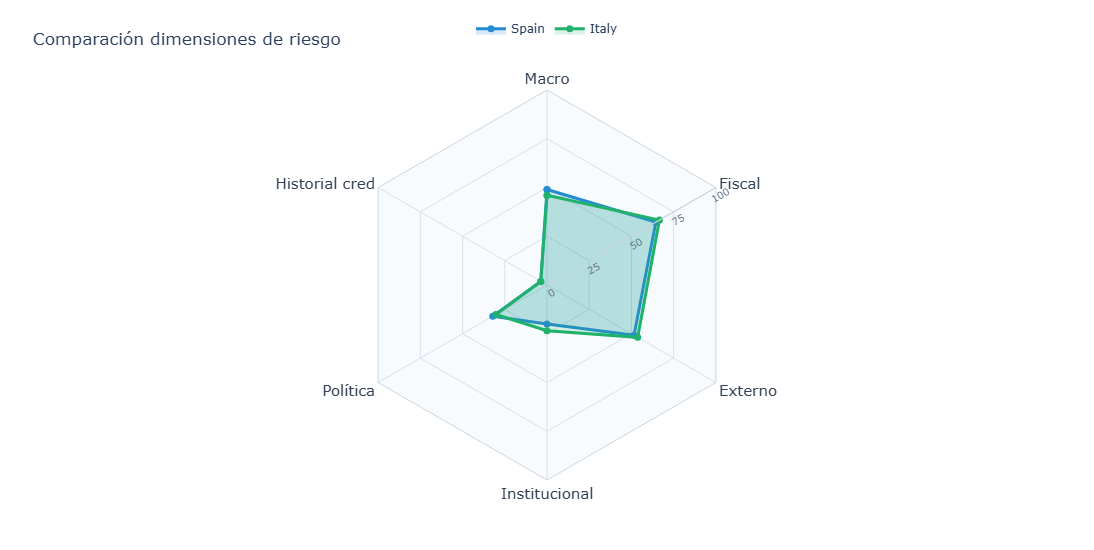

In [112]:
# probamos españa vs italia
fig = plot_risk_radar(
    risk_dimensions_2024,
    "ESP",
    "ITA"
)

fig.show()

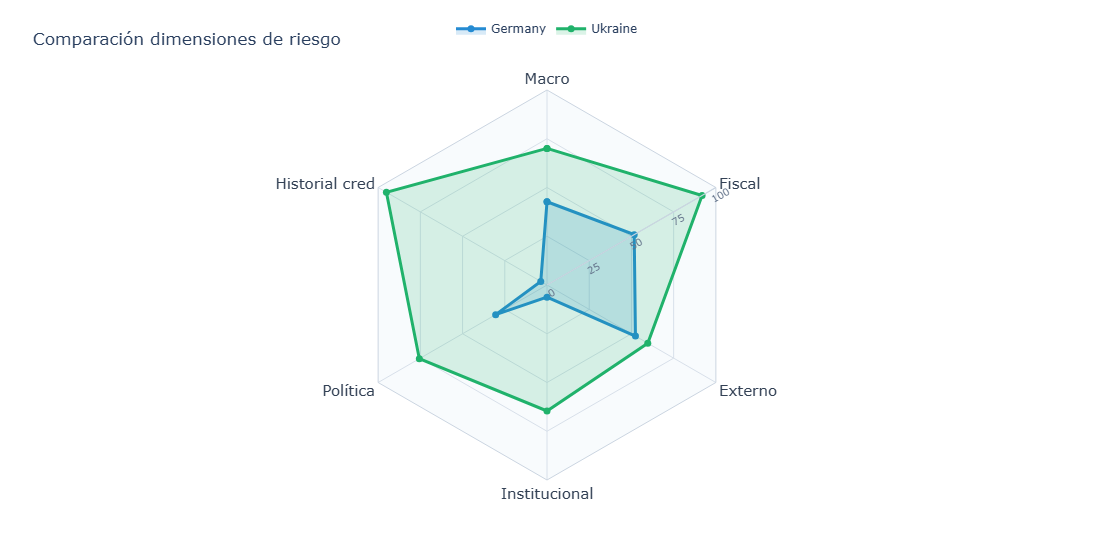

In [113]:
# alemna vs ucrania
fig = plot_risk_radar(
    risk_dimensions_2024,
    "DEU",
    "UKR"
)

fig.show()

## Evolución temporal del Risk Score

Además del perfil de riesgo por dimensiones, la herramienta permite comparar la evolución histórica del riesgo soberano de los países seleccionados.

El Risk Score se obtiene como:

$$
Risk\ Score = 100 - Rating\ Score
$$

De esta forma, valores elevados representan una mayor percepción de riesgo soberano.

La representación temporal permite determinar si las diferencias observadas entre dos países responden a una situación reciente o forman parte de una tendencia estructural a lo largo del tiempo.

In [114]:
DATA_PATH = Path(
    "data/processed"
)

RATINGS_FILE = (
    DATA_PATH
    / "government_credit_rating_mean_2000_2025.csv"
)

ratings = pd.read_csv(
    RATINGS_FILE
)

ratings["risk_score"] = (
    100
    - ratings["rating_score_mean"]
)

print(
    ratings["year"].min(),
    "-",
    ratings["year"].max()
)

2000 - 2025


In [115]:
def plot_risk_evolution(
    ratings,
    country_data,
    country_a,
    country_b
):

    selected = (
        ratings[
            ratings["iso3"].isin(
                [country_a, country_b]
            )
        ]
        .copy()
    )

    # Nombres de los países
    country_names = (
        country_data[
            ["iso3", "country"]
        ]
        .drop_duplicates()
        .set_index("iso3")["country"]
        .to_dict()
    )

    fig = go.Figure()

    colors = {
        country_a: "#258BD2",
        country_b: "#20B26B"
    }

    for country in [
        country_a,
        country_b
    ]:

        country_values = (
            selected[
                selected["iso3"] == country
            ]
            .sort_values("year")
        )

        fig.add_trace(
            go.Scatter(
                x=country_values["year"],
                y=country_values["risk_score"],
                mode="lines+markers",
                name=country_names[country],
                line=dict(
                    color=colors[country],
                    width=3
                ),
                marker=dict(
                    size=6
                )
            )
        )

    fig.update_layout(
        title="Evolución del Risk Score",
        height=450,

        xaxis_title="",
        yaxis_title="Risk Score",

        yaxis=dict(
            range=[0, 100],
            gridcolor="#E8EDF3"
        ),

        xaxis=dict(
            gridcolor="#F1F5F9"
        ),

        hovermode="x unified",

        legend=dict(
            orientation="h",
            x=0.5,
            xanchor="center",
            y=1.12
        ),

        paper_bgcolor="white",
        plot_bgcolor="white",

        margin=dict(
            l=60,
            r=30,
            t=80,
            b=50
        )
    )

    return fig

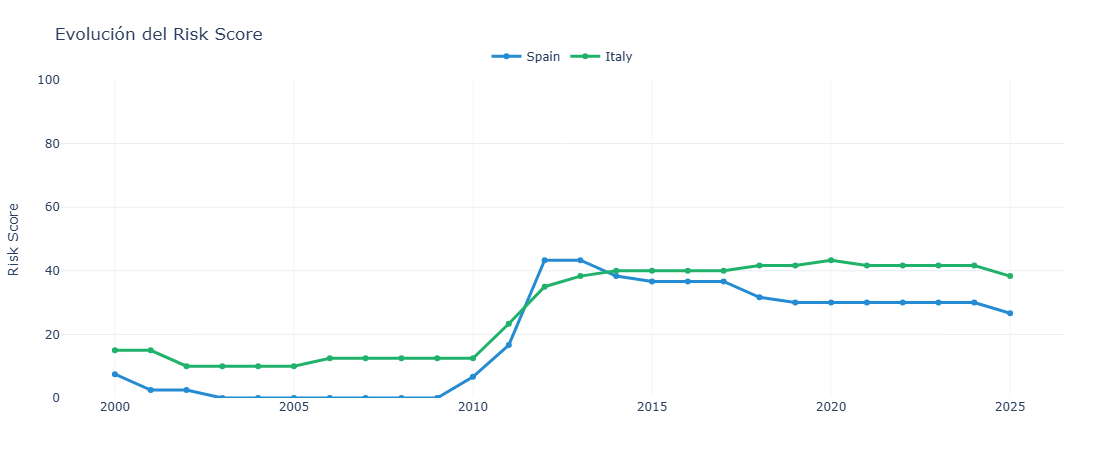

In [116]:
fig = plot_risk_evolution(
    ratings,
    data,
    "ESP",
    "ITA"
)

fig.show()

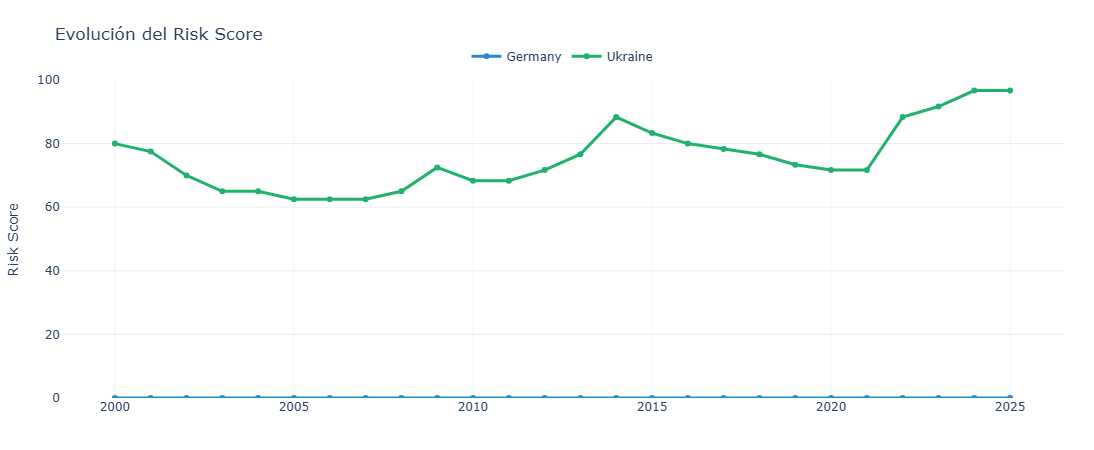

In [117]:
fig = plot_risk_evolution(
    ratings,
    data,
    "DEU",
    "UKR"
)

fig.show()

## Comparación de indicadores observados

Además de las dimensiones normalizadas de riesgo, la herramienta muestra los valores originales de los principales indicadores de ambos países.

Esta tabla permite interpretar las diferencias observadas en el gráfico radar utilizando las unidades económicas originales de cada variable.

In [118]:
comparison_indicators = {
    "PIB real (%)": "gdp_growth_pct",
    "PIB per cápita PPA": "gdp_per_capita_ppp_constant_2021_intl_usd",
    "Inflación (%)": "inflation_cpi_pct",
    "Desempleo (%)": "unemployment_pct",
    "Deuda pública (% PIB)": "government_debt_pct_gdp",
    "Saldo fiscal (% PIB)": "fiscal_balance_pct_gdp",
    "Cuenta corriente (% PIB)": "current_account_balance_pct_gdp",
    "Reservas (meses importaciones)": "reserves_months_imports",
    "Efectividad gubernamental": "government_effectiveness_estimate",
    "Calidad regulatoria": "regulatory_quality_estimate"
}

In [141]:
indicator_direction = {
    "PIB real (%)": "higher_better",
    "PIB per cápita PPA": "higher_better",
    "Inflación (%)": "lower_better",
    "Desempleo (%)": "lower_better",
    "Deuda pública (% PIB)": "lower_better",
    "Saldo fiscal (% PIB)": "higher_better",
    "Cuenta corriente (% PIB)": "higher_better",
    "Reservas (meses importaciones)": "higher_better",
    "Efectividad gubernamental": "higher_better",
    "Calidad regulatoria": "higher_better"
}

In [119]:
indicator_direction = {
    "PIB real (%)": "higher_better",
    "PIB per cápita PPA": "higher_better",
    "Inflación (%)": "lower_better",
    "Desempleo (%)": "lower_better",
    "Deuda pública (% PIB)": "lower_better",
    "Saldo fiscal (% PIB)": "higher_better",
    "Cuenta corriente (% PIB)": "higher_better",
    "Reservas (meses importaciones)": "higher_better",
    "Efectividad gubernamental": "higher_better",
    "Calidad regulatoria": "higher_better"
}

In [120]:
def create_comparison_table(
    data,
    year,
    country_a,
    country_b
):

    selected = (
        data[
            (data["year"] == year)
            & data["iso3"].isin(
                [country_a, country_b]
            )
        ]
        .copy()
    )

    names = (
        selected[
            ["iso3", "country"]
        ]
        .drop_duplicates()
        .set_index("iso3")["country"]
        .to_dict()
    )

    rows = []

    for label, variable in comparison_indicators.items():

        value_a = (
            selected.loc[
                selected["iso3"] == country_a,
                variable
            ]
            .iloc[0]
        )

        value_b = (
            selected.loc[
                selected["iso3"] == country_b,
                variable
            ]
            .iloc[0]
        )

        difference = value_a - value_b

        direction = indicator_direction[label]

        if difference > 0:
            arrow = "↑"

            if direction == "higher_better":
                status = "positive"
            else:
                status = "negative"

        elif difference < 0:
            arrow = "↓"

            if direction == "lower_better":
                status = "positive"
            else:
                status = "negative"

        else:
            arrow = "→"
            status = "neutral"

        rows.append({
            "Indicador": label,
            names[country_a]: value_a,
            names[country_b]: value_b,
            "Diferencia": difference,
            "Flecha": arrow,
            "Estado": status
        })

    return pd.DataFrame(rows)

In [121]:
def style_comparison_table(
    table,
    country_a_name,
    country_b_name
):

    table = table.copy()

    def format_difference(row):

        value = row["Diferencia"]
        arrow = row["Flecha"]

        if row["Estado"] == "positive":
            color = "#15803D"

        elif row["Estado"] == "negative":
            color = "#E63946"

        else:
            color = "#64748B"

        return (
            f'<span style="color:{color};'
            f'font-weight:700;">'
            f'{value:+.2f} {arrow}'
            f'</span>'
        )

    table["Diferencia"] = (
        table.apply(
            format_difference,
            axis=1
        )
    )

    table = table.drop(
        columns=[
            "Flecha",
            "Estado"
        ]
    )

    styled = (
        table.style

        .hide(axis="index")

        .format({
            country_a_name: "{:,.2f}",
            country_b_name: "{:,.2f}"
        })

        .set_properties(**{
            "font-size": "14px",
            "padding": "12px 16px",
            "border-bottom": "1px solid #E8EDF3"
        })

        .set_properties(
            subset=["Indicador"],
            **{
                "font-weight": "600",
                "text-align": "left"
            }
        )
        

        .set_properties(
            subset=[
                country_a_name,
                country_b_name
            ],
            **{
                "text-align": "center",
                "color": "#334155",
                "font-weight": "500"
            }
        )

        .set_properties(
            subset=["Diferencia"],
            **{
                "text-align": "center"
            }
        )

        .set_table_styles([
            {
                "selector": "thead th:first-child",
                "props": [
                    ("text-align", "left")
                ]
            },

            {
                "selector": "table",
                "props": [
                    ("width", "100%"),
                    ("table-layout", "fixed")
                ]
            },
            
            {
                "selector": "thead th:nth-child(1)",
                "props": [
                    ("width", "46%"),
                    ("text-align", "left")
                ]
            },

            {
                "selector": "thead th:nth-child(2)",
                "props": [
                    ("color", "#258BD2"),
                    ("font-weight", "700"),
                    ("border-bottom", "3px solid #258BD2")
                ]
            },

            {
                "selector": "thead th:nth-child(3)",
                "props": [
                    ("color", "#20B26B"),
                    ("font-weight", "700"),
                    ("border-bottom", "3px solid #20B26B")
                ]
            },

            {
                "selector": "thead th:nth-child(4)",
                "props": [
                    ("color", "#111827"),
                    ("font-weight", "700"),
                    ("border-bottom", "3px solid #94A3B8")
                ]
            },
            
                        
            {
                "selector": "thead th:nth-child(2), tbody td:nth-child(2)",
                "props": [
                    ("width", "18%"),
                    ("text-align", "center")
                ]
            },
            
            {
                "selector": "thead th:nth-child(3), tbody td:nth-child(3)",
                "props": [
                    ("width", "18%"),
                    ("text-align", "center")
                ]
            },
            
            {
                "selector": "thead th:nth-child(4), tbody td:nth-child(4)",
                "props": [
                    ("width", "18%"),
                    ("text-align", "center")
                ]
            },
            
            {
                "selector": "thead th",
                "props": [
                    ("background-color", "#F8FAFC"),
                    ("font-weight", "700"),
                    ("padding", "14px")
                ]
            },

            {
                "selector": "thead th:nth-child(2)",
                "props": [
                    ("color", "#258BD2"),
                    ("font-weight", "700")
                ]
            },
            
            {
                "selector": "thead th:nth-child(3)",
                "props": [
                    ("color", "#20B26B"),
                    ("font-weight", "700")
                ]
            },

            {
                "selector": "tbody tr:hover",
                "props": [
                    ("background-color", "#F8FBFD")
                ]
            }
        ])
    )

    return styled

In [122]:
comparison_table = create_comparison_table(
    data,
    2024,
    "ESP",
    "ITA"
)

display(
    style_comparison_table(
        comparison_table,
        "Spain",
        "Italy"
    )
)

Indicador,Spain,Italy,Diferencia
PIB real (%),3.46,0.78,+2.67 ↑
PIB per cápita PPA,"48,460.29","53,284.87",-4824.58 ↓
Inflación (%),2.75,0.98,+1.76 ↑
Desempleo (%),11.40,6.50,+4.90 ↑
Deuda pública (% PIB),101.65,134.74,-33.09 ↓
Saldo fiscal (% PIB),-3.22,-3.35,+0.13 ↑
Cuenta corriente (% PIB),3.18,1.10,+2.09 ↑
Reservas (meses importaciones),1.82,4.02,-2.19 ↓
Efectividad gubernamental,1.11,0.79,+0.32 ↑
Calidad regulatoria,0.62,0.64,-0.02 ↓


## Indicadores principales de comparación

La parte superior de la página de comparación resume cinco indicadores especialmente relevantes para facilitar una primera lectura de la situación de ambos países.

Se muestran el Risk Score, el rating soberano medio, el crecimiento real del PIB, la inflación y la deuda pública. Posteriormente, la tabla y los gráficos permiten profundizar en las diferencias observadas.

In [123]:
def get_comparison_cards(
    data,
    ratings,
    year,
    country_a,
    country_b
):

    indicators_year = (
        data[
            (data["year"] == year)
            & data["iso3"].isin(
                [country_a, country_b]
            )
        ]
        .copy()
    )

    ratings_year = (
        ratings[
            (ratings["year"] == year)
            & ratings["iso3"].isin(
                [country_a, country_b]
            )
        ]
        .copy()
    )

    ratings_year["risk_score"] = (
        100
        - ratings_year["rating_score_mean"]
    )

    names = (
        indicators_year[
            ["iso3", "country"]
        ]
        .drop_duplicates()
        .set_index("iso3")["country"]
        .to_dict()
    )

    result = {}

    for country in [
        country_a,
        country_b
    ]:

        indicators_country = (
            indicators_year[
                indicators_year["iso3"] == country
            ]
            .iloc[0]
        )

        rating_country = (
            ratings_year[
                ratings_year["iso3"] == country
            ]
            .iloc[0]
        )

        result[country] = {
            "country": names[country],

            "Risk Score":
                rating_country["risk_score"],

            "Rating":
                rating_country["rating_score_mean"],

            "PIB real (%)":
                indicators_country["gdp_growth_pct"],

            "Inflación (%)":
                indicators_country["inflation_cpi_pct"],

            "Deuda pública (% PIB)":
                indicators_country[
                    "government_debt_pct_gdp"
                ]
        }

    return result

In [124]:
cards = get_comparison_cards(
    data,
    ratings,
    2024,
    "ESP",
    "ITA"
)

cards

{'ESP': {'country': 'Spain',
  'Risk Score': np.float64(30.0),
  'Rating': np.float64(70.0),
  'PIB real (%)': np.float64(3.45525405630191),
  'Inflación (%)': np.float64(2.747147886618),
  'Deuda pública (% PIB)': np.float64(101.64781312526)},
 'ITA': {'country': 'Italy',
  'Risk Score': np.float64(41.666666666666664),
  'Rating': np.float64(58.333333333333336),
  'PIB real (%)': np.float64(0.783039135276795),
  'Inflación (%)': np.float64(0.982373023061417),
  'Deuda pública (% PIB)': np.float64(134.7353874673)}}

In [125]:
from IPython.display import HTML, display

In [126]:
def show_comparison_cards(
    cards,
    country_a,
    country_b
):

    metrics = [
        ("⚠️", "Risk Score", 1),
        ("📊", "Rating", 1),
        ("📈", "PIB real (%)", 2),
        ("🔥", "Inflación (%)", 2),
        ("🏦", "Deuda pública (% PIB)", 2)
    ]

    country_a_name = (
        cards[country_a]["country"]
    )

    country_b_name = (
        cards[country_b]["country"]
    )

    html = """
    <div style="
        display:grid;
        grid-template-columns:repeat(5, 1fr);
        gap:12px;
        width:100%;
    ">
    """

    for icon, metric, decimals in metrics:

        value_a = cards[country_a][metric]
        value_b = cards[country_b][metric]

        html += f"""
        <div style="
            background:white;
            border:1px solid #E2E8F0;
            border-radius:14px;
            padding:18px;
            min-height:125px;
        ">

            <div style="
                font-size:14px;
                font-weight:700;
                color:#334155;
                margin-bottom:16px;
            ">
                {icon} {metric}
            </div>

            <div style="
                display:flex;
                justify-content:space-between;
                gap:16px;
            ">

                <div>
                    <div style="
                        color:#258BD2;
                        font-size:12px;
                        font-weight:700;
                    ">
                        {country_a_name}
                    </div>

                    <div style="
                        font-size:24px;
                        font-weight:700;
                        color:#1E293B;
                    ">
                        {value_a:.{decimals}f}
                    </div>
                </div>

                <div>
                    <div style="
                        color:#20B26B;
                        font-size:12px;
                        font-weight:700;
                    ">
                        {country_b_name}
                    </div>

                    <div style="
                        font-size:24px;
                        font-weight:700;
                        color:#1E293B;
                    ">
                        {value_b:.{decimals}f}
                    </div>
                </div>

            </div>

        </div>
        """

    html += "</div>"

    display(
        HTML(html)
    )

In [127]:
show_comparison_cards(
    cards,
    "ESP",
    "ITA"
)

## Lectura rápida de la comparación

La idea es incorporar a la herramienta una interpretación automática destinada a facilitar la lectura de los resultados.

El texto identifica qué país presenta actualmente un menor Risk Score y señala la dimensión en la que existe una mayor diferencia entre ambas economías.

Esta interpretación se genera exclusivamente a partir de los indicadores calculados y tiene una finalidad descriptiva.

In [128]:
def create_quick_reading(
    risk_data,
    cards,
    country_a,
    country_b
):

    dimensions = [
        "Macroeconómica",
        "Fiscal",
        "Externa",
        "Institucional",
        "Política y estabilidad",
        "Historial crediticio"
    ]

    name_a = cards[country_a]["country"]
    name_b = cards[country_b]["country"]

    risk_a = cards[country_a]["Risk Score"]
    risk_b = cards[country_b]["Risk Score"]

    row_a = (
        risk_data[
            risk_data["iso3"] == country_a
        ]
        .iloc[0]
    )

    row_b = (
        risk_data[
            risk_data["iso3"] == country_b
        ]
        .iloc[0]
    )

    # Comparación del riesgo global
    if risk_a < risk_b:

        global_text = (
            f"{name_a} presenta un menor riesgo soberano "
            f"que {name_b}, con un Risk Score de "
            f"{risk_a:.1f} frente a {risk_b:.1f}."
        )

    elif risk_b < risk_a:

        global_text = (
            f"{name_b} presenta un menor riesgo soberano "
            f"que {name_a}, con un Risk Score de "
            f"{risk_b:.1f} frente a {risk_a:.1f}."
        )

    else:

        global_text = (
            f"{name_a} y {name_b} presentan el mismo "
            f"Risk Score ({risk_a:.1f})."
        )

    # Diferencias entre dimensiones
    differences = {}

    for dimension in dimensions:

        differences[dimension] = abs(
            row_a[dimension]
            - row_b[dimension]
        )

    largest_dimension = max(
        differences,
        key=differences.get
    )

    value_a = row_a[largest_dimension]
    value_b = row_b[largest_dimension]

    # País con menor vulnerabilidad en esa dimensión
    if value_a < value_b:

        dimension_text = (
            f"La principal diferencia se encuentra en la "
            f"dimensión {largest_dimension.lower()}, "
            f"donde {name_a} presenta menor vulnerabilidad "
            f"relativa que {name_b}."
        )

    elif value_b < value_a:

        dimension_text = (
            f"La principal diferencia se encuentra en la "
            f"dimensión {largest_dimension.lower()}, "
            f"donde {name_b} presenta menor vulnerabilidad "
            f"relativa que {name_a}."
        )

    else:

        dimension_text = ""

    return (
        global_text
        + " "
        + dimension_text
    )

In [129]:
quick_reading = create_quick_reading(
    risk_dimensions_2024,
    cards,
    "ESP",
    "ITA"
)

print(
    quick_reading
)

Spain presenta un menor riesgo soberano que Italy, con un Risk Score de 30.0 frente a 41.7. La principal diferencia se encuentra en la dimensión institucional, donde Spain presenta menor vulnerabilidad relativa que Italy.


## Mapa de localización de los países comparados

La página de comparación incorpora un mapa mundial que permite identificar visualmente las dos economías seleccionadas.

El resto de países se representa en gris, mientras que los dos países analizados mantienen los mismos colores utilizados en el resto de la página:

- azul para el País A;
- verde para el País B.

El mapa tiene una finalidad exclusivamente visual y facilita la localización geográfica de las economías comparadas.

In [130]:
def plot_comparison_map(
    country_data,
    country_a,
    country_b
):

    names = (
        country_data[
            ["iso3", "country"]
        ]
        .drop_duplicates()
        .set_index("iso3")["country"]
        .to_dict()
    )

    name_a = names[country_a]
    name_b = names[country_b]

    fig = go.Figure()

    # País A
    fig.add_trace(
        go.Choropleth(
            locations=[country_a],
            z=[1],
            locationmode="ISO-3",

            colorscale=[
                [0, "#258BD2"],
                [1, "#258BD2"]
            ],

            showscale=False,

            name=name_a,
            showlegend=True,

            text=[name_a],

            hovertemplate=(
                "<b>%{text}</b>"
                "<extra></extra>"
            ),

            marker_line_color="white",
            marker_line_width=1
        )
    )

    # País B
    fig.add_trace(
        go.Choropleth(
            locations=[country_b],
            z=[1],
            locationmode="ISO-3",

            colorscale=[
                [0, "#20B26B"],
                [1, "#20B26B"]
            ],

            showscale=False,

            name=name_b,
            showlegend=True,

            text=[name_b],

            hovertemplate=(
                "<b>%{text}</b>"
                "<extra></extra>"
            ),

            marker_line_color="white",
            marker_line_width=1
        )
    )

    fig.update_geos(

        projection_type="natural earth",

        showframe=False,
        showcoastlines=True,
        coastlinecolor="#CBD5E1",

        showcountries=True,
        countrycolor="white",

        showland=True,
        landcolor="#D9DEE5",

        showocean=True,
        oceancolor="white",

        bgcolor="white"
    )

    fig.update_layout(

        title=dict(
            text="Localización de los países",
            x=0.03
        ),

        height=480,

        legend=dict(
            orientation="h",
            x=0.5,
            xanchor="center",
            y=1.03
        ),

        margin=dict(
            l=5,
            r=5,
            t=70,
            b=5
        ),

        paper_bgcolor="white"
    )

    return fig

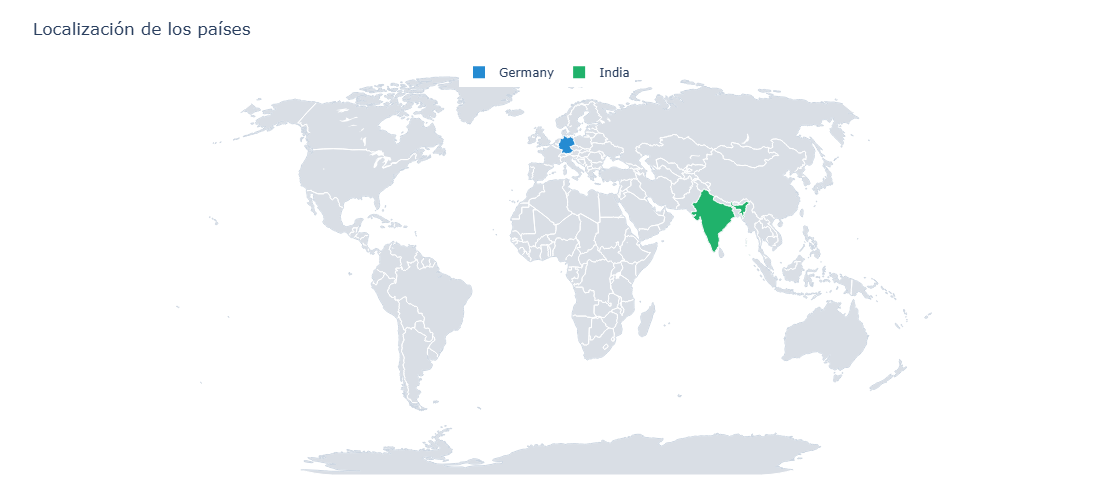

In [131]:
fig = plot_comparison_map(
    data,
    "DEU",
    "IND"
)

fig.show()

Ahora se crearan unos nuevos documentos en :

TFM/
│
├── data/
├── herramienta_interactiva/
├── utils/                  ← NUEVA
│
├── app.py
├── TFM 7.- dimensiones de riesgo herramienta.ipynb
└── ...

con dos archivos:
__init__.py (completamente vacio)
risk_dimensions.py

A continuación se realizan unas pruebas de importación:

In [132]:
from utils.risk_dimensions import (
    calculate_risk_dimensions
)

In [133]:
test_dimensions = (
    calculate_risk_dimensions(
        data,
        2024
    )
)

display(
    test_dimensions[
        test_dimensions["iso3"]
        .isin([
            "ESP",
            "ITA",
            "DEU",
            "UKR"
        ])
    ][
        [
            "country",
            "Macroeconómica",
            "Fiscal",
            "Externa",
            "Institucional",
            "Política y estabilidad",
            "Historial crediticio"
        ]
    ]
    .round(1)
)

,country,Macroeconómica,Fiscal,Externa,Institucional,Política y estabilidad,Historial crediticio
1274,Germany,42.7,51.6,52.4,6.3,30.4,3.7
1499,Spain,49.0,64.5,51.5,20.0,32.1,3.7
2399,Italy,46.1,66.6,53.7,23.4,30.3,3.7
5049,Ukraine,70.1,91.8,59.7,64.6,75.6,95.1


In [134]:
from utils.comparison import (
    plot_risk_radar,
    plot_risk_evolution,
    create_comparison_table,
    style_comparison_table,
    get_comparison_cards,
    create_quick_reading
)

In [135]:
test_cards = get_comparison_cards(
    data,
    ratings,
    2024,
    "ESP",
    "ITA"
)

test_cards

{'ESP': {'country': 'Spain',
  'Risk Score': np.float64(30.0),
  'Rating': np.float64(70.0),
  'PIB real (%)': np.float64(3.45525405630191),
  'Inflación (%)': np.float64(2.747147886618),
  'Deuda pública (% PIB)': np.float64(101.64781312526)},
 'ITA': {'country': 'Italy',
  'Risk Score': np.float64(41.666666666666664),
  'Rating': np.float64(58.333333333333336),
  'PIB real (%)': np.float64(0.783039135276795),
  'Inflación (%)': np.float64(0.982373023061417),
  'Deuda pública (% PIB)': np.float64(134.7353874673)}}

In [136]:
test_table = create_comparison_table(
    data,
    2024,
    "ESP",
    "ITA"
)

display(
    style_comparison_table(
        test_table,
        "Spain",
        "Italy"
    )
)

Indicador,Spain,Italy,Diferencia
PIB real (%),3.46,0.78,+2.67 ↑
PIB per cápita PPA,"48,460.29","53,284.87",-4824.58 ↓
Inflación (%),2.75,0.98,+1.76 ↑
Desempleo (%),11.40,6.50,+4.90 ↑
Deuda pública (% PIB),101.65,134.74,-33.09 ↓
Saldo fiscal (% PIB),-3.22,-3.35,+0.13 ↑
Cuenta corriente (% PIB),3.18,1.10,+2.09 ↑
Reservas (meses importaciones),1.82,4.02,-2.19 ↓
Efectividad gubernamental,1.11,0.79,+0.32 ↑
Calidad regulatoria,0.62,0.64,-0.02 ↓


In [137]:
test_reading = create_quick_reading(
    risk_dimensions_2024,
    test_cards,
    "ESP",
    "ITA"
)

print(test_reading)

Spain presenta un menor riesgo soberano que Italy, con un Risk Score de 30.0 frente a 41.7. La principal diferencia se encuentra en la dimensión institucional, donde Spain presenta menor vulnerabilidad relativa que Italy.


---
# 3. PÁGINA CLUSTERES
## Análisis de clústeres

El objetivo es identificar grupos de países que presentan perfiles de riesgo similares a partir de un conjunto de variables económicas, fiscales, externas, institucionales, políticas y de historial crediticio.

Para facilitar la interpretación, las variables se normalizan previamente y se aplica un Análisis de Componentes Principales (PCA), que permite representar los países en dos dimensiones.

Posteriormente, se aplica un algoritmo K-Means para identificar grupos de países con características comunes.

## Selección de variables para PCA y clústeres

Antes de aplicar PCA y K-Means se revisa el conjunto completo de variables explicativas de la base integrada.

La selección tiene como objetivo conservar información económica relevante, evitando variables identificativas, objetivos de predicción, variables categóricas no adecuadas para el análisis y redundancias excesivas.

También se analiza la disponibilidad de cada indicador en el año seleccionado, ya que la cobertura puede variar a lo largo del periodo 2000–2024.

In [142]:
# Columnas que no deben entrar en el clustering
metadata_columns = [
    "iso3",
    "iso2",
    "country",
    "region",
    "income_level",
    "year",
    "economic_period"
]

target_columns = [
    column
    for column in data.columns
    if column.endswith("_t1")
]

target_columns += [
    column
    for column in [
        "rating_year",
        "target_available_t1"
    ]
    if column in data.columns
]

# Variables explicativas
cluster_candidates = [
    column
    for column in data.columns
    if column not in metadata_columns + target_columns
]

print(
    "Variables candidatas:",
    len(cluster_candidates)
)

Variables candidatas: 52


In [143]:
test_year = 2024

cluster_year_data = (
    data[
        data["year"] == test_year
    ]
    .copy()
)

cluster_audit = pd.DataFrame({
    "Variable": cluster_candidates,

    "Tipo": [
        str(data[variable].dtype)
        for variable in cluster_candidates
    ],

    "Missing (%)": [
        cluster_year_data[variable]
        .isna()
        .mean()
        * 100
        for variable in cluster_candidates
    ],

    "Valores únicos": [
        cluster_year_data[variable]
        .nunique(
            dropna=True
        )
        for variable in cluster_candidates
    ]
})

cluster_audit = (
    cluster_audit
    .sort_values(
        "Missing (%)"
    )
    .reset_index(
        drop=True
    )
)

display(
    cluster_audit.round(2)
)

,Variable,Tipo,Missing (%),Valores únicos
0,default_previous_5y,int64,0.00,2
1,default_previous_10y,int64,0.00,2
2,years_since_last_default,int64,0.00,27
3,never_default_history_dummy,int64,0.00,2
4,sovereign_debt_in_default_usd_mn,float64,0.00,76
5,sovereign_default_dummy,int64,0.00,2
6,political_stability_estimate,float64,5.07,203
7,control_of_corruption_estimate,float64,5.07,202
8,rule_of_law_estimate,float64,5.07,206
9,regulatory_quality_estimate,float64,5.99,202


**REGLAS SELECCIÓN DINÁMICA PARA CADA AÑO/REGIÓN**
1. Seleccionar año
2. Seleccionar región si procede
3. Partir del conjunto de variables elegibles
4. Eliminar variables con > 40 % de missing
5. Eliminar variables constantes en esa muestra
6. Eliminar variables no numéricas
7. Imputar los missing restantes con la mediana
8. Estandarizar
9. PCA
10. K-Means

In [144]:
cluster_fixed_exclusions = [
    "head_of_government",

    # Variables de conflicto redundantes
    "battle_related_deaths",
    "log_battle_related_deaths",

    # Redundancia comercial
    "trade_openness_pct_gdp",

    # Default actual redundante
    "sovereign_default_dummy"
]

In [145]:
cluster_eligible_variables = [
    variable
    for variable in cluster_candidates
    if variable not in cluster_fixed_exclusions
]

print(
    "Variables candidatas iniciales:",
    len(cluster_candidates)
)

print(
    "Variables elegibles:",
    len(cluster_eligible_variables)
)

Variables candidatas iniciales: 52
Variables elegibles: 47


In [146]:
def select_cluster_variables(
    data,
    year,
    variables,
    region=None,
    max_missing=40
):

    selected_data = (
        data[
            data["year"] == year
        ]
        .copy()
    )

    # Filtrar región si se selecciona
    if region is not None:

        selected_data = (
            selected_data[
                selected_data["region"] == region
            ]
            .copy()
        )

    selected_variables = []
    excluded_rows = []

    for variable in variables:

        # Excluir variables no numéricas
        if not pd.api.types.is_numeric_dtype(
            selected_data[variable]
        ):

            excluded_rows.append({
                "Variable": variable,
                "Motivo": "No numérica"
            })

            continue

        missing_pct = (
            selected_data[variable]
            .isna()
            .mean()
            * 100
        )

        # Excluir por missing
        if missing_pct > max_missing:

            excluded_rows.append({
                "Variable": variable,
                "Motivo": f"Missing {missing_pct:.1f}%"
            })

            continue

        unique_values = (
            selected_data[variable]
            .nunique(
                dropna=True
            )
        )

        # Excluir variables constantes
        if unique_values <= 1:

            excluded_rows.append({
                "Variable": variable,
                "Motivo": "Sin variabilidad"
            })

            continue

        selected_variables.append(
            variable
        )

    excluded_table = pd.DataFrame(
        excluded_rows
    )

    return (
        selected_data,
        selected_variables,
        excluded_table
    )

In [147]:
cluster_data_2024, variables_2024, excluded_2024 = (
    select_cluster_variables(
        data,
        year=2024,
        variables=cluster_eligible_variables
    )
)

print(
    "Países:",
    len(cluster_data_2024)
)

print(
    "Variables utilizadas:",
    len(variables_2024)
)

print(
    "\nVariables seleccionadas:"
)

print(
    variables_2024
)

print(
    "\nVariables excluidas:"
)

display(
    excluded_2024
)

Países: 217
Variables utilizadas: 35

Variables seleccionadas:
['exchange_rate_lcu_per_usd', 'gdp_growth_pct', 'gdp_per_capita_constant_2015_usd', 'gdp_per_capita_ppp_constant_2021_intl_usd', 'gdp_ppp_constant_2021_intl_usd', 'gross_savings_pct_gdp', 'inflation_cpi_pct', 'investment_pct_gdp', 'unemployment_pct', 'fiscal_balance_pct_gdp', 'government_debt_pct_gdp', 'government_expenditure_pct_gdp', 'government_revenue_pct_gdp', 'primary_balance_pct_gdp', 'net_interest_payments_pct_gdp', 'current_account_balance_pct_gdp', 'exports_growth_pct', 'exports_pct_gdp', 'fdi_net_inflows_pct_gdp', 'imports_pct_gdp', 'reserves_months_imports', 'control_of_corruption_estimate', 'government_effectiveness_estimate', 'political_stability_estimate', 'regulatory_quality_estimate', 'rule_of_law_estimate', 'voice_accountability_estimate', 'electoral_democracy_index', 'government_change_dummy', 'government_changes_previous_5y', 'sovereign_debt_in_default_usd_mn', 'default_previous_5y', 'default_previous_10

,Variable,Motivo
0,external_debt_pct_gni,Missing 49.3%
1,external_debt_service_pct_exports,Missing 49.8%
2,external_debt_stocks_current_usd,Missing 45.6%
3,reserves_pct_external_debt,Missing 55.8%
4,short_term_debt_pct_reserves,Missing 55.8%
5,bank_npl_pct_gross_loans,Missing 40.6%
6,real_interest_rate_pct,Missing 59.9%
7,head_of_government_tenure_years,Missing 46.1%
8,average_government_duration_since_2000,Missing 43.3%
9,global_competitiveness_index,Missing 100.0%


## Preparación de la muestra para el análisis de clústeres

Una vez seleccionadas automáticamente las variables con suficiente cobertura, se analiza la disponibilidad de información de cada país.

Se excluyen aquellas economías que presentan más de un 40 % de valores ausentes entre las variables finalmente seleccionadas. Los valores ausentes restantes se imputan mediante la mediana de cada indicador.

Posteriormente, todas las variables se estandarizan para evitar que las diferencias de escala condicionen el PCA y el algoritmo K-Means.

In [148]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [149]:
def prepare_cluster_data(
    selected_data,
    selected_variables,
    max_country_missing=40
):

    cluster_data = (
        selected_data[
            ["iso3", "country", "region"]
            + selected_variables
        ]
        .copy()
    )

    # Missing por país
    country_missing = (
        cluster_data[
            selected_variables
        ]
        .isna()
        .mean(axis=1)
        * 100
    )

    # Conservar países con suficiente información
    cluster_data = (
        cluster_data[
            country_missing <= max_country_missing
        ]
        .copy()
    )

    # Matriz de variables
    X = (
        cluster_data[
            selected_variables
        ]
        .copy()
    )

    # Imputación con mediana
    imputer = SimpleImputer(
        strategy="median"
    )

    X_imputed = imputer.fit_transform(
        X
    )

    # Estandarización
    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        X_imputed
    )

    return (
        cluster_data,
        X_scaled,
        imputer,
        scaler
    )

In [150]:
cluster_sample_2024, X_cluster_2024, imputer_2024, scaler_2024 = (
    prepare_cluster_data(
        cluster_data_2024,
        variables_2024
    )
)

print(
    "Variables utilizadas:",
    len(variables_2024)
)

print(
    "Países disponibles inicialmente:",
    len(cluster_data_2024)
)

print(
    "Países incluidos finalmente:",
    len(cluster_sample_2024)
)

print(
    "Países excluidos por falta de datos:",
    len(cluster_data_2024)
    - len(cluster_sample_2024)
)

print(
    "Dimensión matriz final:",
    X_cluster_2024.shape
)

Variables utilizadas: 35
Países disponibles inicialmente: 217
Países incluidos finalmente: 191
Países excluidos por falta de datos: 26
Dimensión matriz final: (191, 35)


## Análisis de Componentes Principales

Para facilitar la representación visual de los países se aplica un Análisis de Componentes Principales (PCA) sobre las variables previamente imputadas y estandarizadas.

El PCA permite proyectar la información multidimensional en un plano formado por las dos primeras componentes principales.

Estas dos componentes se utilizan únicamente con fines de visualización. El algoritmo K-Means se aplicará posteriormente sobre el conjunto completo de variables estandarizadas, evitando perder información relevante durante la formación de los clústeres.

In [151]:
import numpy as np

from sklearn.decomposition import PCA

In [152]:
pca_full = PCA()

X_pca_full_2024 = pca_full.fit_transform(
    X_cluster_2024
)

explained_variance = (
    pca_full.explained_variance_ratio_
)

cumulative_variance = (
    np.cumsum(
        explained_variance
    )
)

In [153]:
n_components_80 = (
    np.argmax(
        cumulative_variance >= 0.80
    )
    + 1
)

n_components_90 = (
    np.argmax(
        cumulative_variance >= 0.90
    )
    + 1
)

print(
    "Componentes para explicar 80 %:",
    n_components_80
)

print(
    "Componentes para explicar 90 %:",
    n_components_90
)

print(
    "Varianza PC1:",
    round(
        explained_variance[0] * 100,
        2
    ),
    "%"
)

print(
    "Varianza PC2:",
    round(
        explained_variance[1] * 100,
        2
    ),
    "%"
)

Componentes para explicar 80 %: 13
Componentes para explicar 90 %: 17
Varianza PC1: 29.16 %
Varianza PC2: 8.67 %


In [154]:
pca_variance_table = pd.DataFrame({
    "Componente": [
        f"PC{i + 1}"
        for i in range(
            len(explained_variance)
        )
    ],

    "Varianza (%)":
        explained_variance
        * 100,

    "Varianza acumulada (%)":
        cumulative_variance
        * 100
})

display(
    pca_variance_table
    .head(15)
    .round(2)
)

,Componente,Varianza (%),Varianza acumulada (%)
0,PC1,29.16,29.16
1,PC2,8.67,37.82
2,PC3,6.38,44.20
3,PC4,6.09,50.29
4,PC5,5.62,55.91
5,PC6,5.08,60.99
6,PC7,3.75,64.74
7,PC8,3.47,68.22
8,PC9,3.25,71.47
9,PC10,2.81,74.28


In [155]:
pca = PCA(
    n_components=n_components_80
)

X_pca_2024 = (
    pca.fit_transform(
        X_cluster_2024
    )
)

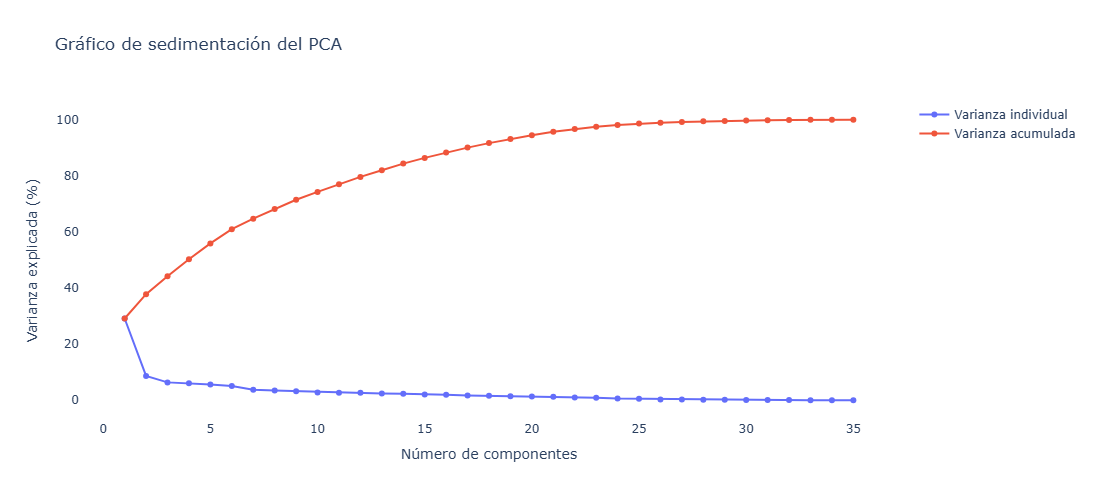

In [156]:
import plotly.graph_objects as go

components = np.arange(
    1,
    len(explained_variance) + 1
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=components,
        y=explained_variance * 100,
        mode="lines+markers",
        name="Varianza individual"
    )
)

fig.add_trace(
    go.Scatter(
        x=components,
        y=cumulative_variance * 100,
        mode="lines+markers",
        name="Varianza acumulada"
    )
)

fig.update_layout(
    title="Gráfico de sedimentación del PCA",
    xaxis_title="Número de componentes",
    yaxis_title="Varianza explicada (%)",
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

In [157]:
eigenvalues = (
    pca_full.explained_variance_
)

n_components_kaiser = (
    eigenvalues > 1
).sum()

print(
    "Componentes según Kaiser:",
    n_components_kaiser
)

Componentes según Kaiser: 9


In [158]:
x = np.arange(
    1,
    len(explained_variance) + 1
)

y = explained_variance

# Normalizar
x_norm = (
    (x - x.min())
    / (x.max() - x.min())
)

y_norm = (
    (y - y.min())
    / (y.max() - y.min())
)

# Línea entre primer y último punto
line = (
    y_norm[0]
    + (
        y_norm[-1] - y_norm[0]
    )
    * x_norm
)

# Distancia respecto a la línea
distances = (
    y_norm - line
)

n_components_elbow = (
    np.argmax(distances)
    + 1
)

print(
    "Componentes según codo:",
    n_components_elbow
)

Componentes según codo: 1


In [159]:
print(
    "80 % varianza:",
    n_components_80
)

print(
    "90 % varianza:",
    n_components_90
)

print(
    "Kaiser:",
    n_components_kaiser
)

print(
    "Codo:",
    n_components_elbow
)

80 % varianza: 13
90 % varianza: 17
Kaiser: 9
Codo: 1


In [160]:
def select_pca_components(
    X_scaled,
    min_variance=0.60,
    min_component_variance=0.04,
    max_components=10
):

    pca_full = PCA()

    pca_full.fit(
        X_scaled
    )

    explained_variance = (
        pca_full.explained_variance_ratio_
    )

    cumulative_variance = (
        np.cumsum(
            explained_variance
        )
    )

    n_selected = None

    for i in range(
        len(explained_variance)
    ):

        n_components = i + 1

        enough_total_variance = (
            cumulative_variance[i]
            >= min_variance
        )

        small_new_component = (
            explained_variance[i]
            < min_component_variance
        )

        if (
            enough_total_variance
            and small_new_component
        ):

            n_selected = n_components
            break

    # Si no se encuentra antes
    if n_selected is None:

        n_selected = min(
            np.argmax(
                cumulative_variance
                >= min_variance
            ) + 1,
            max_components
        )

    # Límite máximo
    n_selected = min(
        n_selected,
        max_components
    )

    return {
        "n_components": n_selected,

        "explained_variance": (
            cumulative_variance[
                n_selected - 1
            ]
        ),

        "individual_variance": (
            explained_variance[
                n_selected - 1
            ]
        ),

        "explained_variance_all":
            explained_variance,

        "cumulative_variance":
            cumulative_variance
    }

In [161]:
pca_selection_2024 = (
    select_pca_components(
        X_cluster_2024
    )
)

print(
    "Componentes seleccionadas:",
    pca_selection_2024[
        "n_components"
    ]
)

print(
    "Varianza acumulada:",
    round(
        pca_selection_2024[
            "explained_variance"
        ]
        * 100,
        2
    ),
    "%"
)

print(
    "Varianza de la última componente:",
    round(
        pca_selection_2024[
            "individual_variance"
        ]
        * 100,
        2
    ),
    "%"
)

Componentes seleccionadas: 7
Varianza acumulada: 64.74 %
Varianza de la última componente: 3.75 %


## PCA definitivo para el análisis de clústeres

Una vez determinado automáticamente el número de componentes principales, se ajusta el PCA definitivo sobre la matriz de variables estandarizadas.

Todas las componentes seleccionadas se conservarán para el posterior análisis K-Means, mientras que las dos primeras componentes se utilizarán para representar gráficamente los países en un plano bidimensional.

In [162]:
# Número de componentes seleccionado automáticamente
n_components_2024 = (
    pca_selection_2024[
        "n_components"
    ]
)

# PCA definitivo
pca_2024 = PCA(
    n_components=n_components_2024
)

X_pca_2024 = (
    pca_2024.fit_transform(
        X_cluster_2024
    )
)

print(
    "Componentes utilizadas:",
    n_components_2024
)

print(
    "Varianza explicada:",
    round(
        pca_2024
        .explained_variance_ratio_
        .sum()
        * 100,
        2
    ),
    "%"
)

print(
    "Dimensión matriz PCA:",
    X_pca_2024.shape
)

Componentes utilizadas: 7
Varianza explicada: 64.74 %
Dimensión matriz PCA: (191, 7)


In [163]:
cluster_pca_2024 = (
    cluster_sample_2024[
        [
            "iso3",
            "country",
            "region"
        ]
    ]
    .copy()
)

cluster_pca_2024[
    "PC1"
] = X_pca_2024[:, 0]

cluster_pca_2024[
    "PC2"
] = X_pca_2024[:, 1]

display(
    cluster_pca_2024.head()
)

,iso3,country,region,PC1,PC2
24,ABW,Aruba,Latin America & Caribbean,3.974088,1.264245
49,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",-4.735685,1.026956
74,AGO,Angola,Sub-Saharan Africa,-3.183868,0.736830
99,ALB,Albania,Europe & Central Asia,-0.884418,0.253713
149,ARE,United Arab Emirates,"Middle East, North Africa, Afghanistan & Pakistan",3.417992,3.048956


In [164]:
# Dividir el eje PC1 en 10 zonas ... o 20
cluster_pca_2024["pc1_group"] = pd.qcut(
    cluster_pca_2024["PC1"],
    q=20,
    duplicates="drop"
)

cluster_pca_2024["pc1_group"] = (
    cluster_pca_2024["pc1_group"]
    .astype(str)
)
label_countries = []

# Países representativos por zonas de PC1
for group in cluster_pca_2024["pc1_group"].dropna().unique():

    group_data = cluster_pca_2024[
        cluster_pca_2024["pc1_group"] == group
    ]

    selected = pd.concat([
        group_data.nlargest(1, "PC2"),
        group_data.nsmallest(1, "PC2")
    ])

    label_countries.extend(
        selected["country"].tolist()
    )

# Extremos del eje X
country_left = (
    cluster_pca_2024
    .nsmallest(1, "PC1")
    ["country"]
    .iloc[0]
)

country_right = (
    cluster_pca_2024
    .nlargest(1, "PC1")
    ["country"]
    .iloc[0]
)

# Extremos del eje Y
country_bottom = (
    cluster_pca_2024
    .nsmallest(1, "PC2")
    ["country"]
    .iloc[0]
)

country_top = (
    cluster_pca_2024
    .nlargest(1, "PC2")
    ["country"]
    .iloc[0]
)

# Añadir extremos
label_countries.extend([
    country_left,
    country_right,
    country_bottom,
    country_top
])

# Añadir siempre España
if "Spain" in cluster_pca_2024["country"].values:

    label_countries.append(
        "Spain"
    )

# Eliminar duplicados
label_countries = list(
    dict.fromkeys(
        label_countries
    )
)

# Crear etiquetas
cluster_pca_2024["label"] = np.where(
    cluster_pca_2024["country"].isin(
        label_countries
    ),
    cluster_pca_2024["country"],
    ""
)

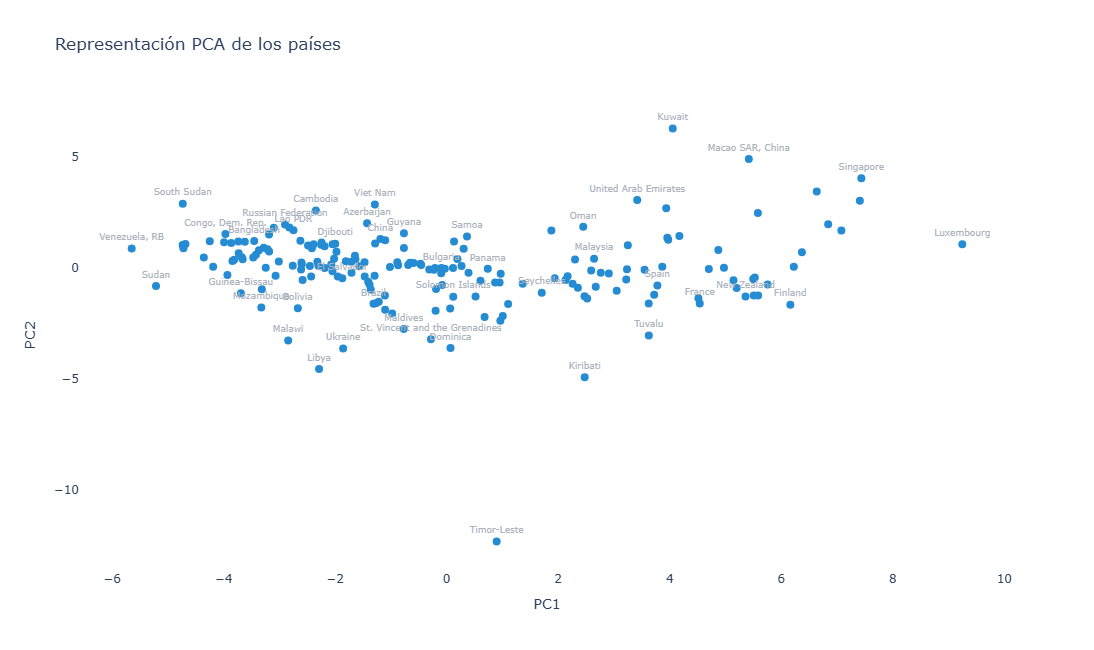

In [165]:
fig = px.scatter(
    cluster_pca_2024,
    x="PC1",
    y="PC2",
    text="label",
    hover_name="country",
    hover_data={
        "iso3": True,
        "region": True,
        "PC1": ":.2f",
        "PC2": ":.2f",
        "pc1_group": False,
        "label": False
    },
    title="Representación PCA de los países"
)

fig.update_traces(
    marker=dict(
        size=8,
        color="#258BD2"
    ),
    textposition="top center",
    textfont=dict(
        size=9,
        color="#AAB2BD"
    )
)

fig.update_layout(
    height=650,
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

## Selección del número de clústeres

Para determinar el número de clústeres se comparan varias soluciones de K-Means.

La selección se apoya principalmente en el coeficiente Silhouette, que mide la separación entre grupos y la cohesión interna de cada clúster. También se analiza la inercia como referencia visual mediante el método del codo.

El número de clústeres se determina automáticamente para cada combinación de año, región y conjunto de variables.

In [166]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [167]:
from sklearn.metrics import (
    davies_bouldin_score,
    calinski_harabasz_score
)

cluster_results = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(
        X_pca_2024
    )

    cluster_results.append({
        "K": k,

        "Inercia":
            model.inertia_,

        "Silhouette":
            silhouette_score(
                X_pca_2024,
                labels
            ),

        "Davies-Bouldin":
            davies_bouldin_score(
                X_pca_2024,
                labels
            ),

        "Calinski-Harabasz":
            calinski_harabasz_score(
                X_pca_2024,
                labels
            ),

        "Cluster mínimo":
            pd.Series(
                labels
            )
            .value_counts()
            .min()
    })

cluster_evaluation = pd.DataFrame(
    cluster_results
)

display(
    cluster_evaluation.round(3)
)

,K,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz,Cluster mínimo
0,2,2865.056,0.363,1.169,96.512,57
1,3,2497.086,0.206,1.554,68.926,47
2,4,2266.174,0.204,1.330,56.715,3
3,5,2069.990,0.213,1.339,50.726,5
4,6,1912.549,0.201,1.316,46.731,3
5,7,1760.688,0.206,1.320,44.717,3
6,8,1667.949,0.168,1.348,41.694,1


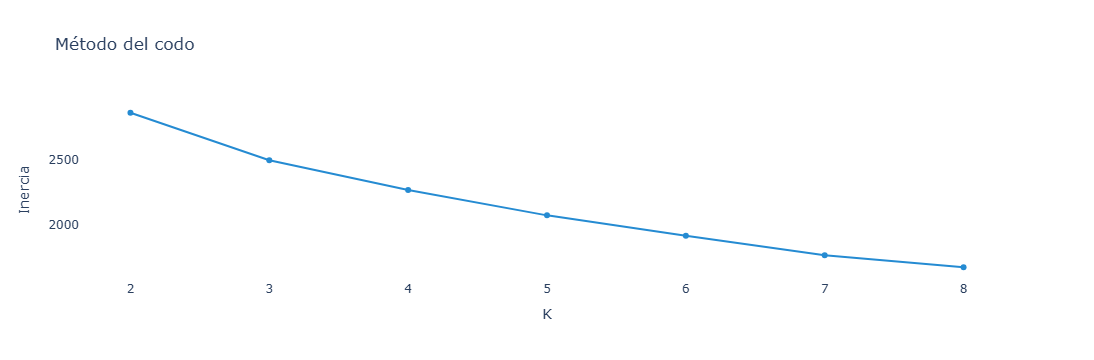

In [168]:
fig = px.line(
    cluster_evaluation,
    x="K",
    y="Inercia",
    markers=True,
    title="Método del codo"
)

fig.update_traces(
    line=dict(
        color="#258BD2"
    )
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

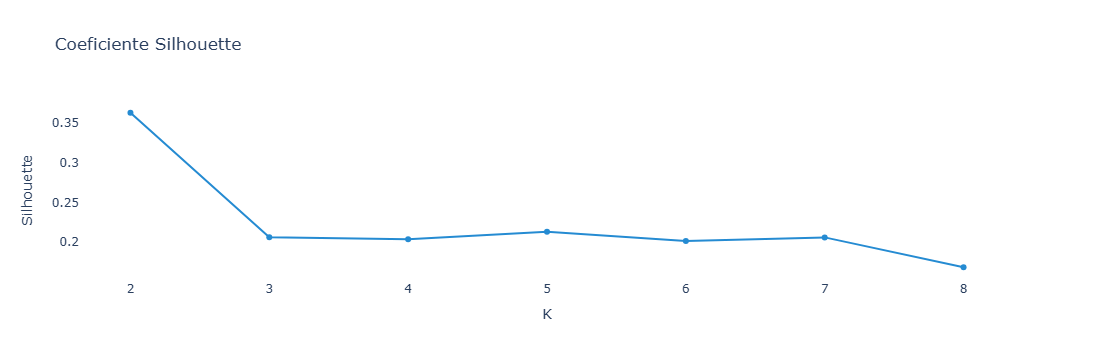

In [169]:
fig = px.line(
    cluster_evaluation,
    x="K",
    y="Silhouette",
    markers=True,
    title="Coeficiente Silhouette"
)

fig.update_traces(
    line=dict(
        color="#258BD2"
    )
)

fig.update_layout(
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

In [170]:
def select_number_clusters(
    X,
    k_min=3,
    k_max=6,
    min_cluster_pct=0.02,
    min_cluster_abs=3
):

    results = []

    # Tamaño mínimo permitido
    min_size = max(
        min_cluster_abs,
        int(
            np.ceil(
                len(X)
                * min_cluster_pct
            )
        )
    )

    for k in range(
        k_min,
        k_max + 1
    ):

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=20
        )

        labels = model.fit_predict(
            X
        )

        cluster_sizes = (
            pd.Series(labels)
            .value_counts()
        )

        results.append({
            "K": k,
            "Inercia": model.inertia_,
            "Silhouette":
                silhouette_score(
                    X,
                    labels
                ),
            "Davies-Bouldin":
                davies_bouldin_score(
                    X,
                    labels
                ),
            "Calinski-Harabasz":
                calinski_harabasz_score(
                    X,
                    labels
                ),
            "Cluster mínimo":
                cluster_sizes.min()
        })

    results = pd.DataFrame(
        results
    )

    # Soluciones con tamaño suficiente
    valid_results = (
        results[
            results["Cluster mínimo"]
            >= min_size
        ]
        .copy()
    )

    # Si todas fallasen, usar todas
    if valid_results.empty:

        valid_results = (
            results.copy()
        )

    # Mejor Silhouette
    best_k = int(
        valid_results.loc[
            valid_results[
                "Silhouette"
            ].idxmax(),
            "K"
        ]
    )

    return (
        best_k,
        results
    )

In [171]:
best_k_2024, cluster_evaluation_2024 = (
    select_number_clusters(
        X_pca_2024
    )
)

print(
    "Número de clústeres seleccionado:",
    best_k_2024
)

display(
    cluster_evaluation_2024.round(3)
)

Número de clústeres seleccionado: 5


,K,Inercia,Silhouette,Davies-Bouldin,Calinski-Harabasz,Cluster mínimo
0,3,2497.086,0.206,1.554,68.926,47
1,4,2266.174,0.204,1.330,56.715,3
2,5,2069.990,0.213,1.339,50.726,5
3,6,1912.549,0.201,1.316,46.731,3


## K-Means definitivo

Una vez seleccionado automáticamente el número de clústeres, se ajusta el modelo K-Means definitivo utilizando las componentes principales retenidas.

Los clústeres obtenidos representan grupos de países con perfiles similares en el conjunto de indicadores analizados. La numeración inicial de los clústeres es arbitraria, por lo que posteriormente se analizarán sus características para asignar una interpretación económica a cada grupo.

In [172]:
kmeans_2024 = KMeans(
    n_clusters=best_k_2024,
    random_state=42,
    n_init=20
)

cluster_labels_2024 = (
    kmeans_2024.fit_predict(
        X_pca_2024
    )
)

cluster_pca_2024["Cluster"] = (
    cluster_labels_2024 + 1
)

In [173]:
cluster_sizes_2024 = (
    cluster_pca_2024["Cluster"]
    .value_counts()
    .sort_index()
)

display(
    cluster_sizes_2024
    .rename("Número de países")
    .to_frame()
)

,Número de países
Cluster,
1,5
2,5
3,48
4,62
5,71


In [174]:
RATINGS_FILE = (
    Path("data/processed")
    / "government_credit_rating_mean_2000_2025.csv"
)

ratings = pd.read_csv(
    RATINGS_FILE
)

print(
    ratings.shape
)

print(
    ratings[
        [
            "iso3",
            "year",
            "rating_score_mean"
        ]
    ].head()
)

(4160, 18)
  iso3  year  rating_score_mean
0  ABW  2000                NaN
1  ABW  2001                NaN
2  ABW  2002                NaN
3  ABW  2003                NaN
4  ABW  2004                NaN


In [175]:
ratings_2024 = (
    ratings[
        ratings["year"] == 2024
    ][
        [
            "iso3",
            "rating_score_mean"
        ]
    ]
    .copy()
)

ratings_2024["Risk_Score"] = (
    100
    - ratings_2024["rating_score_mean"]
)

cluster_pca_2024 = (
    cluster_pca_2024
    .merge(
        ratings_2024[
            [
                "iso3",
                "Risk_Score"
            ]
        ],
        on="iso3",
        how="left"
    )
)

In [176]:
cluster_risk_2024 = (
    cluster_pca_2024
    .groupby(
        "Cluster"
    )["Risk_Score"]
    .mean()
    .sort_values()
)

display(
    cluster_risk_2024
    .round(2)
    .rename(
        "Risk Score medio"
    )
    .to_frame()
)

,Risk Score medio
Cluster,
1,10.00
3,20.74
5,64.21
2,70.00
4,73.18


In [177]:
risk_colors = [
    "#258BD2",  # Muy bajo
    "#20B26B",  # Bajo
    "#F2C94C",  # Medio
    "#F2994A",  # Alto
    "#EB5757"   # Muy alto
]

ordered_clusters = (
    cluster_risk_2024
    .index
    .tolist()
)

cluster_color_map = dict(
    zip(
        ordered_clusters,
        risk_colors
    )
)

cluster_color_map

{1: '#258BD2', 3: '#20B26B', 5: '#F2C94C', 2: '#F2994A', 4: '#EB5757'}

In [178]:
risk_names = [
    "Muy bajo",
    "Bajo",
    "Medio",
    "Alto",
    "Muy alto"
]

cluster_risk_name = dict(
    zip(
        ordered_clusters,
        risk_names
    )
)

cluster_pca_2024[
    "Perfil de riesgo"
] = (
    cluster_pca_2024[
        "Cluster"
    ]
    .map(
        cluster_risk_name
    )
)

In [179]:
cluster_pca_2024[
    "Cluster_display"
] = (
    cluster_pca_2024[
        "Cluster"
    ]
    .apply(
        lambda x:
        f"Clúster {x} · "
        f"{cluster_risk_name[x]}"
    )
)

In [180]:
cluster_display_colors = {
    f"Clúster {cluster} · {cluster_risk_name[cluster]}":
    cluster_color_map[cluster]

    for cluster
    in ordered_clusters
}

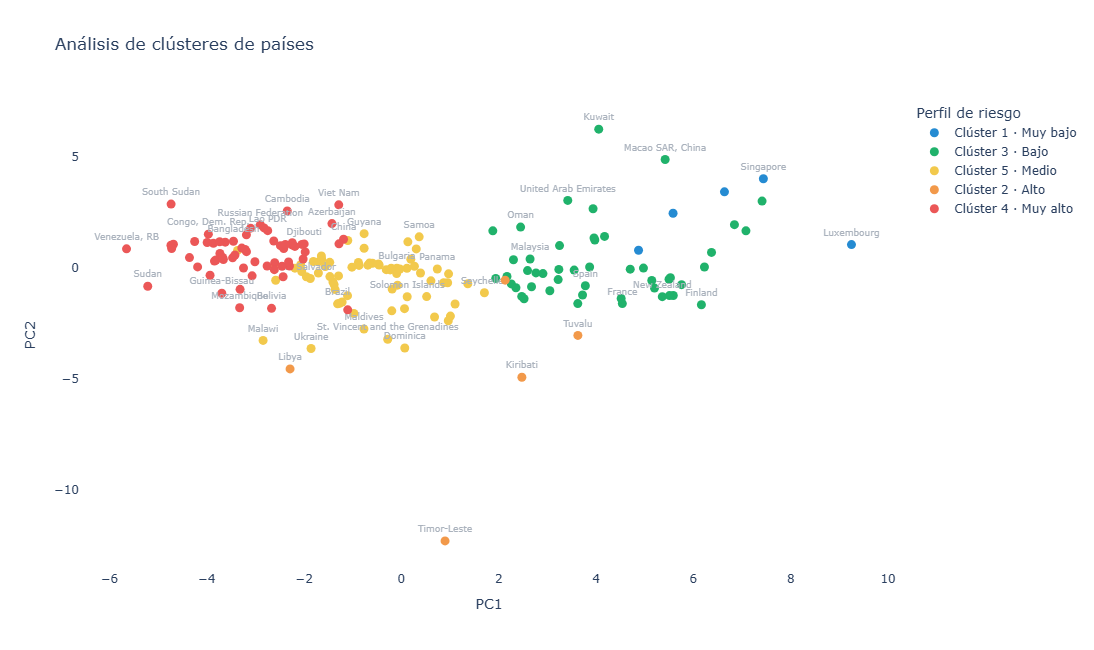

In [181]:
fig = px.scatter(
    cluster_pca_2024,
    x="PC1",
    y="PC2",
    color="Cluster_display",
    text="label",
    hover_name="country",
    hover_data={
        "iso3": True,
        "region": True,
        "Risk_Score": ":.1f",
        "PC1": ":.2f",
        "PC2": ":.2f",
        "Cluster_display": False,
        "pc1_group": False,
        "label": False
    },
    color_discrete_map=cluster_display_colors,
    category_orders={
        "Cluster_display": [
            f"Clúster {cluster} · {cluster_risk_name[cluster]}"
            for cluster in ordered_clusters
        ]
    },
    title="Análisis de clústeres de países"
)

fig.update_traces(
    marker=dict(
        size=9
    ),
    textposition="top center",
    textfont=dict(
        size=9,
        color="#AAB2BD"
    )
)

fig.update_layout(
    height=650,
    plot_bgcolor="white",
    paper_bgcolor="white",
    legend_title_text="Perfil de riesgo"
)

fig.show()

## Caracterización de los clústeres

Una vez identificados los grupos mediante K-Means, se analizan sus características económicas mediante las seis dimensiones de riesgo construidas previamente.

Para cada clúster se calcula el valor medio de las dimensiones macroeconómica, fiscal, externa, institucional, política y de estabilidad, e historial crediticio.

Estos indicadores no intervienen en la asignación posterior de etiquetas a los países, sino que se utilizan para interpretar económicamente los perfiles obtenidos mediante el análisis de clústeres.

In [182]:
dimension_columns = [
    "Macroeconómica",
    "Fiscal",
    "Externa",
    "Institucional",
    "Política y estabilidad",
    "Historial crediticio"
]

# Dimensiones del año 2024
dimensions_2024 = (
    risk_dimensions_2024
    .copy()
)

# Unir clústeres y dimensiones
cluster_dimensions_2024 = (
    cluster_pca_2024[
        [
            "iso3",
            "country",
            "Cluster",
            "Perfil de riesgo",
            "Risk_Score"
        ]
    ]
    .merge(
        dimensions_2024[
            ["iso3"] + dimension_columns
        ],
        on="iso3",
        how="left"
    )
)

In [189]:
cluster_dimension_summary = (
    cluster_dimensions_2024
    .groupby(
        [
            "Cluster",
            "Perfil de riesgo"
        ],
        as_index=False
    )
    .agg(
        {
            "country": "count",
            "Risk_Score": "mean",
            **{
                dimension: "mean"
                for dimension in dimension_columns
            }
        }
    )
)

cluster_dimension_summary = (
    cluster_dimension_summary
    .rename(
        columns={
            "country": "Países",
            "Risk_Score": "Risk Score medio"
        }
    )
    .sort_values(
        "Risk Score medio"
    )
    .reset_index(drop=True)
)

display(
    cluster_dimension_summary.round(1)
)

,Cluster,Perfil de riesgo,Países,Risk Score medio,Macroeconómica,Fiscal,Externa,Institucional,Política y estabilidad,Historial crediticio
0,1,Muy bajo,5,10.0,37.2,36.3,31.1,13.1,27.1,10.0
1,3,Bajo,48,20.7,41.3,45.4,48.6,19.6,30.1,11.2
2,5,Medio,71,64.2,51.8,57.0,51.2,48.3,48.5,68.3
3,2,Alto,5,70.0,58.9,43.4,57.6,56.1,60.2,28.4
4,4,Muy alto,62,73.2,54.9,46.6,51.9,79.3,77.4,86.6


In [190]:
# Países de ejemplo por clúster
cluster_examples = (
    cluster_pca_2024
    .groupby("Cluster")["country"]
    .apply(
        lambda x: ", ".join(
            sorted(x)[:4]
        )
    )
    .reset_index(
        name="Países (ejemplos)"
    )
)

In [195]:
dimension_columns = [
    "Macroeconómica",
    "Fiscal",
    "Externa",
    "Institucional",
    "Política y estabilidad",
    "Historial crediticio"
]

def get_cluster_drivers(row):

    values = (
        row[dimension_columns]
        .sort_values(
            ascending=False
        )
    )

    return (
        values.index[0]
        + " · "
        + values.index[1]
    )


cluster_dimension_summary[
    "Rasgos dominantes"
] = (
    cluster_dimension_summary
    .apply(
        get_cluster_drivers,
        axis=1
    )
)

In [196]:
cluster_table = (
    cluster_dimension_summary
    .merge(
        cluster_examples,
        on="Cluster",
        how="left"
    )
)

In [197]:
cluster_table = cluster_table[
    [
        "Cluster",
        "Perfil de riesgo",
        "Países (ejemplos)",
        "Países",
        "Risk Score medio",
        "Rasgos dominantes"
    ]
].copy()

In [198]:
risk_profile_colors = {
    "Muy bajo": "#258BD2",
    "Bajo": "#20B26B",
    "Medio": "#F2C94C",
    "Alto": "#F2994A",
    "Muy alto": "#EB5757"
}

In [199]:
cluster_table["Color"] = (
    cluster_table[
        "Perfil de riesgo"
    ]
    .map(
        risk_profile_colors
    )
)

In [200]:
def build_cluster_table_html(
    df
):

    header = """
    <table style="
        width:100%;
        border-collapse:collapse;
        background:white;
        font-size:14px;
    ">

        <thead>
            <tr style="
                border-bottom:1px solid #CBD5E1;
                background:#F8FAFC;
            ">
                <th style="
                    text-align:left;
                    padding:14px;
                ">
                    Clúster
                </th>

                <th style="
                    text-align:left;
                    padding:14px;
                ">
                    Perfil
                </th>

                <th style="
                    text-align:left;
                    padding:14px;
                ">
                    Países (ejemplos)
                </th>

                <th style="
                    text-align:center;
                    padding:14px;
                ">
                    # Países
                </th>

                <th style="
                    text-align:center;
                    padding:14px;
                ">
                    Risk Score medio
                </th>

                <th style="
                    text-align:left;
                    padding:14px;
                ">
                    Rasgos dominantes
                </th>
            </tr>
        </thead>

        <tbody>
    """

    rows = ""

    for _, row in df.iterrows():

        color = row["Color"]

        rows += f"""
        <tr style="
            border-bottom:1px solid #E2E8F0;
        ">

            <td style="
                padding:14px;
                font-weight:700;
                border-bottom:3px solid {color};
            ">
                Clúster {int(row["Cluster"])}
            </td>

            <td style="
                padding:14px;
                font-weight:600;
            ">
                {row["Perfil de riesgo"]}
            </td>

            <td style="
                padding:14px;
                color:#475569;
            ">
                {row["Países (ejemplos)"]}
            </td>

            <td style="
                padding:14px;
                text-align:center;
            ">
                {int(row["Países"])}
            </td>

            <td style="
                padding:14px;
                text-align:center;
                font-weight:700;
                color:{color};
            ">
                {row["Risk Score medio"]:.1f}
            </td>

            <td style="
                padding:14px;
                color:#334155;
            ">
                {row["Rasgos dominantes"]}
            </td>

        </tr>
        """

    footer = """
        </tbody>
    </table>
    """

    return (
        header
        + rows
        + footer
    )

In [201]:
from IPython.display import HTML

HTML(
    build_cluster_table_html(
        cluster_table
    )
)

Clúster,Perfil,Países (ejemplos),# Países,Risk Score medio,Rasgos dominantes
Clúster 1,Muy bajo,"Hong Kong SAR, China, Ireland, Luxembourg, Malta",5,10.0,Macroeconómica · Fiscal
Clúster 3,Bajo,"Aruba, Australia, Austria, Bahamas, The",48,20.7,Externa · Fiscal
Clúster 5,Medio,"Albania, Antigua and Barbuda, Argentina, Armenia",71,64.2,Historial crediticio · Fiscal
Clúster 2,Alto,"Kiribati, Libya, Naoero, Timor-Leste",5,70.0,Política y estabilidad · Macroeconómica
Clúster 4,Muy alto,"Afghanistan, Algeria, Angola, Azerbaijan",62,73.2,Historial crediticio · Institucional


In [210]:
import plotly.express as px

display_dimensions = {
    "Macroeconómica": "Macro",
    "Fiscal": "Fiscal",
    "Externa": "Externo",
    "Institucional": "Institucional",
    "Política y estabilidad": "Política",
    "Historial crediticio": "Historial cred."
}

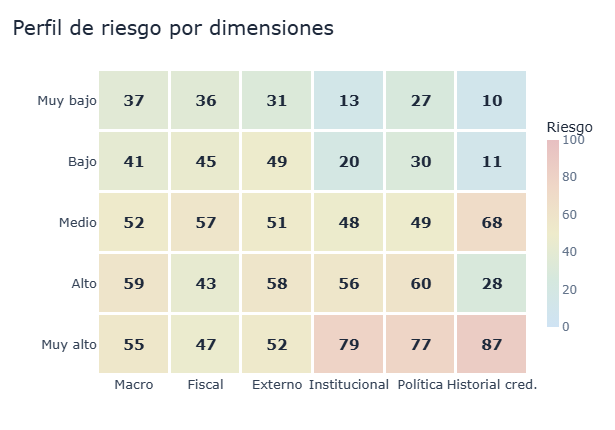

In [221]:

hedisplay_dimensions = {
    "Macroeconómica": "Macro",
    "Fiscal": "Fiscal",
    "Externa": "Externo",
    "Institucional": "Institucional",
    "Política y estabilidad": "Política",
    "Historial crediticio": "Historial cred."
}

heatmap_data = (
    cluster_dimension_summary
    .set_index(
        "Perfil de riesgo"
    )[
        dimension_columns
    ]
    .rename(
        columns=display_dimensions
    )
)

fig_heatmap = go.Figure(
    data=go.Heatmap(
        z=heatmap_data.values,
        x=heatmap_data.columns,
        y=heatmap_data.index,

        zmin=0,
        zmax=100,

        colorscale=[
            [0.00, "#CFE3F4"],  # azul muy suave
            [0.25, "#D5E8DE"],  # verde frío
            [0.50, "#EEEBCB"],  # amarillo suave
            [0.75, "#EFD7C7"],  # naranja suave
            [1.00, "#E7BFC1"]   # rojo suave
        ],

        text=np.round(
            heatmap_data.values
        ).astype(int),

        texttemplate="<b>%{text}</b>",

        textfont=dict(
            size=15,
            color="#1E293B"
        ),

        xgap=3,
        ygap=3,

        hovertemplate=(
            "<b>%{y}</b><br>"
            "%{x}: %{z:.1f}<br>"
            "<extra></extra>"
        ),

        colorbar=dict(
            title="Riesgo",
            thickness=12,
            len=0.75,
            outlinewidth=0,
            tickfont=dict(
                color="#64748B"
            ),
            title_font=dict(
                color="#1E293B"
            )
        )
    )
)

fig_heatmap.update_layout(
    title=dict(
        text="Perfil de riesgo por dimensiones",
        x=0.02,
        xanchor="left",
        font=dict(
            size=20,
            color="#1E293B"
        )
    ),

    height=430,

    margin=dict(
        l=90,
        r=80,
        t=70,
        b=55
    ),

    paper_bgcolor="white",
    plot_bgcolor="white",

    xaxis=dict(
        title="",
        side="bottom",
        tickangle=0,
        tickfont=dict(
            size=13,
            color="#334155"
        ),
        showgrid=False
    ),

    yaxis=dict(
        title="",
        autorange="reversed",
        tickfont=dict(
            size=13,
            color="#334155"
        ),
        showgrid=False
    )
)

fig_heatmap.show()

In [202]:
cluster_size_plot = (
    cluster_dimension_summary[
        [
            "Cluster",
            "Perfil de riesgo",
            "Países"
        ]
    ]
    .copy()
)

cluster_size_plot["Etiqueta"] = (
    "Clúster "
    + cluster_size_plot["Cluster"].astype(str)
    + " · "
    + cluster_size_plot["Perfil de riesgo"]
)

cluster_size_plot["Color"] = (
    cluster_size_plot[
        "Perfil de riesgo"
    ]
    .map(
        risk_profile_colors
    )
)

# Ordenar de menor a mayor riesgo
cluster_size_plot = (
    cluster_size_plot
    .merge(
        cluster_dimension_summary[
            [
                "Cluster",
                "Risk Score medio"
            ]
        ],
        on="Cluster"
    )
    .sort_values(
        "Risk Score medio"
    )
)

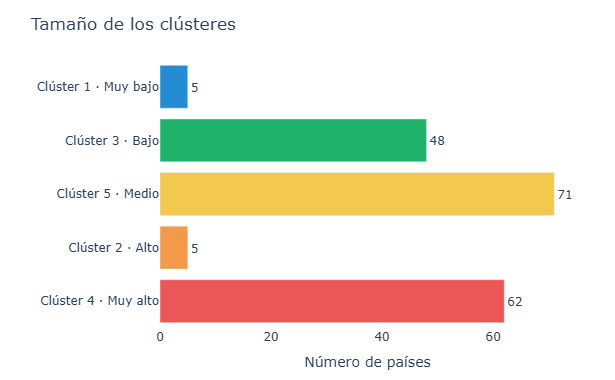

In [203]:
fig_cluster_size = go.Figure()

for _, row in cluster_size_plot.iterrows():

    fig_cluster_size.add_trace(
        go.Bar(
            x=[row["Países"]],
            y=[row["Etiqueta"]],
            orientation="h",
            marker_color=row["Color"],
            text=[row["Países"]],
            textposition="outside",
            showlegend=False
        )
    )

fig_cluster_size.update_layout(
    title="Tamaño de los clústeres",
    xaxis_title="Número de países",
    yaxis_title="",
    height=380,
    margin=dict(
        l=120,
        r=40,
        t=60,
        b=50
    ),
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig_cluster_size.update_yaxes(
    autorange="reversed"
)

fig_cluster_size.show()

In [204]:
def get_cluster_strengths(row):

    values = (
        row[dimension_columns]
        .sort_values()
    )

    return (
        values.index[0]
        + " y "
        + values.index[1]
    )

In [205]:
quick_findings = []

for _, row in cluster_dimension_summary.iterrows():

    cluster = int(
        row["Cluster"]
    )

    profile = (
        row["Perfil de riesgo"]
    )

    risk = (
        row["Risk Score medio"]
    )

    vulnerabilities = (
        get_cluster_drivers(
            row
        )
        .replace(
            " · ",
            " y "
        )
    )

    strengths = (
        get_cluster_strengths(
            row
        )
    )

    if profile in [
        "Muy bajo",
        "Bajo"
    ]:

        text = (
            f"El clúster {cluster} presenta un perfil de "
            f"riesgo {profile.lower()}, destacando su "
            f"fortaleza en {strengths.lower()}."
        )

    elif profile == "Medio":

        text = (
            f"El clúster {cluster} presenta un riesgo "
            f"intermedio, con mayor vulnerabilidad en "
            f"{vulnerabilities.lower()}."
        )

    else:

        text = (
            f"El clúster {cluster} presenta un perfil de "
            f"riesgo {profile.lower()}, principalmente "
            f"asociado a {vulnerabilities.lower()}."
        )

    quick_findings.append(
        text
    )

In [206]:
for finding in quick_findings:

    print(
        "✓",
        finding
    )

✓ El clúster 1 presenta un perfil de riesgo muy bajo, destacando su fortaleza en historial crediticio y institucional.
✓ El clúster 3 presenta un perfil de riesgo bajo, destacando su fortaleza en historial crediticio y institucional.
✓ El clúster 5 presenta un riesgo intermedio, con mayor vulnerabilidad en historial crediticio y fiscal.
✓ El clúster 2 presenta un perfil de riesgo alto, principalmente asociado a política y estabilidad y macroeconómica.
✓ El clúster 4 presenta un perfil de riesgo muy alto, principalmente asociado a historial crediticio y institucional.


TFM/
│
├── app.py
│
└── utils/
    ├── comparison.py
    ├── risk_dimensions.py
    └── clustering.py      ← NUEVO

In [233]:
import os

print("Carpeta actual:")
print(os.getcwd())

from utils.clustering import run_cluster_analysis

print("IMPORT OK")

Carpeta actual:
C:\Users\pedro.lopez\Desktop\MASTER\TFM
IMPORT OK


In [234]:
import importlib
import utils.clustering as clustering

importlib.reload(
    clustering
)

run_cluster_analysis = clustering.run_cluster_analysis

In [235]:
cluster_results_2024 = run_cluster_analysis(
    data=data,
    ratings=ratings,
    year=2024
)

print(
    "Países iniciales:",
    cluster_results_2024["countries_initial"]
)

print(
    "Países finales:",
    cluster_results_2024["countries_final"]
)

print(
    "Variables utilizadas:",
    len(cluster_results_2024["variables"])
)

print(
    "Componentes PCA:",
    cluster_results_2024["n_components"]
)

print(
    "Varianza explicada:",
    round(
        cluster_results_2024["pca_variance"] * 100,
        2
    ),
    "%"
)

print(
    "Número de clústeres:",
    cluster_results_2024["best_k"]
)

Países iniciales: 217
Países finales: 191
Variables utilizadas: 35
Componentes PCA: 7
Varianza explicada: 64.74 %
Número de clústeres: 5


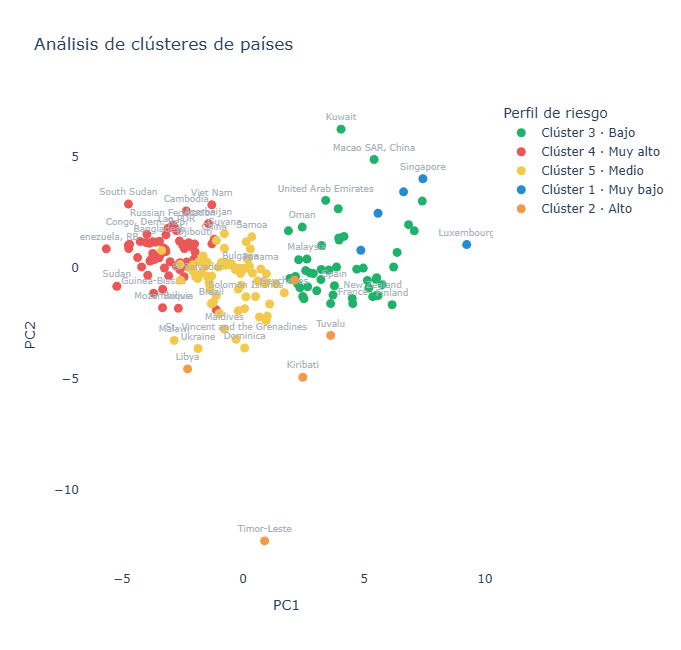

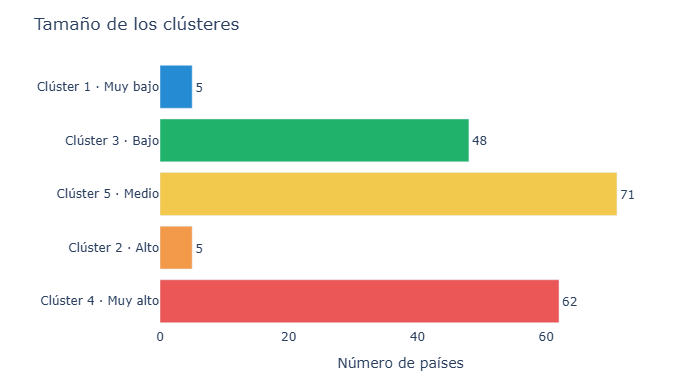

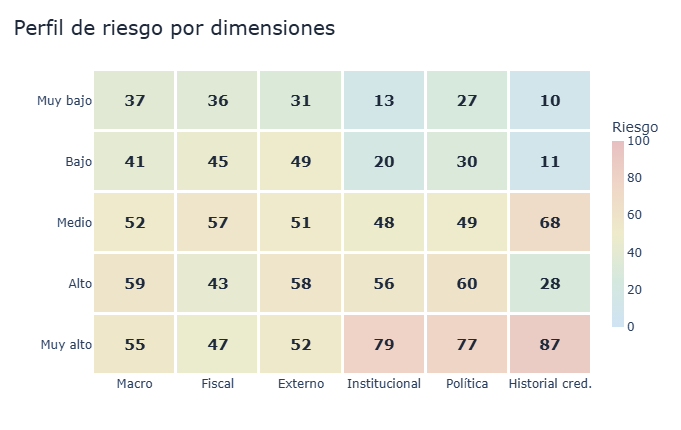

✓ El clúster 1 presenta un perfil de riesgo muy bajo, destacando su fortaleza en historial crediticio y institucional.
✓ El clúster 3 presenta un perfil de riesgo bajo, destacando su fortaleza en historial crediticio y institucional.
✓ El clúster 5 presenta un riesgo intermedio, con mayor vulnerabilidad en historial crediticio y fiscal.
✓ El clúster 2 presenta un perfil de riesgo alto, principalmente asociado a política y estabilidad y macroeconómica.
✓ El clúster 4 presenta un perfil de riesgo muy alto, principalmente asociado a historial crediticio y institucional.


In [236]:
cluster_results_2024["fig_pca"].show()
cluster_results_2024["fig_sizes"].show()
cluster_results_2024["fig_heatmap"].show()

from IPython.display import HTML

HTML(
    cluster_results_2024[
        "table_html"
    ]
)

for finding in cluster_results_2024["findings"]:
    print("✓", finding)

In [237]:
from IPython.display import HTML, display

print(
    "Existe table_html:",
    "table_html" in cluster_results_2024
)

print(
    "Longitud HTML:",
    len(cluster_results_2024["table_html"])
)

display(
    HTML(
        cluster_results_2024["table_html"]
    )
)

Existe table_html: True
Longitud HTML: 8303


Clúster,Perfil,Países (ejemplos),# Países,Risk Score medio,Rasgos dominantes
Clúster 1,Muy bajo,"Hong Kong SAR, China, Ireland, Luxembourg, Malta",5,10.0,Macroeconómica · Fiscal
Clúster 3,Bajo,"Aruba, Australia, Austria, Bahamas, The",48,20.7,Externa · Fiscal
Clúster 5,Medio,"Albania, Antigua and Barbuda, Argentina, Armenia",71,64.2,Historial crediticio · Fiscal
Clúster 2,Alto,"Kiribati, Libya, Naoero, Timor-Leste",5,70.0,Política y estabilidad · Macroeconómica
Clúster 4,Muy alto,"Afghanistan, Algeria, Angola, Azerbaijan",62,73.2,Historial crediticio · Institucional


---
# 4. PÁGINA PREDICCIÓN


In [254]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np

MODEL_PATH = Path(
    "data/model/random_forest_final.joblib"
)

model_package = joblib.load(
    MODEL_PATH
)

model = model_package["model"]
preprocessor = model_package["preprocessor"]
features = model_package["features"]

print("Modelo cargado")
print("Número de variables:", len(features))

Modelo cargado
Número de variables: 71


In [255]:
prediction = 54.0
current_rating = 48.0

change = prediction - current_rating

print(prediction)
print(change)

54.0
6.0


In [260]:
def risk_score_to_rating(score):

    if score >= 97.5:
        return "AAA"
    elif score >= 92.5:
        return "AA+"
    elif score >= 87.5:
        return "AA"
    elif score >= 82.5:
        return "AA-"
    elif score >= 77.5:
        return "A+"
    elif score >= 72.5:
        return "A"
    elif score >= 67.5:
        return "A-"
    elif score >= 62.5:
        return "BBB+"
    elif score >= 57.5:
        return "BBB"
    elif score >= 52.5:
        return "BBB-"
    elif score >= 47.5:
        return "BB+"
    elif score >= 42.5:
        return "BB"
    elif score >= 37.5:
        return "BB-"
    elif score >= 32.5:
        return "B+"
    elif score >= 27.5:
        return "B"
    elif score >= 22.5:
        return "B-"
    elif score >= 17.5:
        return "CCC+"
    elif score >= 12.5:
        return "CCC"
    elif score >= 7.5:
        return "CCC-"
    elif score >= 2.5:
        return "CC / C"
    else:
        return "D"

In [304]:
html = f"""

<div style="
    background:#FFFFFF;
    border:1px solid #D8E6F3;
    border-radius:16px;
    padding:25px;
    width:350px;
    box-sizing:border-box;
    font-family:Arial;
">

<div style="
    font-size:16px;
    color:#334155;
    margin-bottom:25px;
">
Predicción del modelo
</div>


<div style="
    text-align:center;
    font-size:55px;
    font-weight:700;
    color:#1E293B;
">
{prediction:.1f}
<span style="
    font-size:24px;
    font-weight:400;
">
/100
</span>
</div>


<div style="
    text-align:center;
    margin-top:10px;
    color:#64748B;
    font-size:15px;
">
Riesgo país estimado
</div>


<div style="
    background:#FEF3C7;
    color:#92400E;
    border-radius:20px;
    padding:8px 20px;
    width:max-content;
    margin:20px auto;
    font-size:14px;
">
🟠 Riesgo medio
</div>

<div style="
text-align:center;
color:#64748B;
font-size:14px;
margin-top:15px;
">
Equivalencia aproximada agencias
</div>

<div style="
text-align:center;
font-size:32px;
font-weight:700;
color:#1E293B;
margin-top:5px;
">
BB
</div>

<hr style="
border:none;
border-top:1px solid #E2E8F0;
">


<div style="
text-align:center;
color:#64748B;
font-size:14px;
margin-top:20px;
">
Cambio respecto al rating actual
</div>


<div style="
text-align:center;
font-size:28px;
font-weight:700;
color:#658AC2;
margin-top:10px;
">
↑ +{change:.1f} puntos
</div>


</div>

"""

display(
    HTML(html)
)

In [293]:
# GRAFICO
from pathlib import Path
import joblib
import pandas as pd
import plotly.graph_objects as go


MODEL_DATA_PATH = Path(
    "data/model"
)


# Datos preparados para Rama B
data_41 = joblib.load(
    MODEL_DATA_PATH / "notebook_4_1_prepared_data.joblib"
)


# Modelo definitivo
model_package = joblib.load(
    MODEL_DATA_PATH / "random_forest_final.joblib"
)


model = model_package["model"]
preprocessor = model_package["preprocessor"]
features = model_package["features"]

In [294]:
panel_B = pd.concat(
    [
        data_41["train"],
        data_41["validation"],
        data_41["test"]
    ],
    axis=0
).copy()


panel_B.shape

(3434, 108)

In [295]:
X_hist = panel_B[
    features
]


X_hist_processed = preprocessor.transform(
    X_hist
)


panel_B["model_prediction"] = (
    model.predict(
        X_hist_processed
    )
)

C:\Users\pedro.lopez\AppData\Local\anaconda3\envs\tfm_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [296]:
panel_B[
    [
        "country",
        "year",
        "region",
        "rating_score_mean_t1",
        "model_prediction"
    ]
].head()

,country,year,region,rating_score_mean_t1,model_prediction
0,Aruba,2009,Latin America & Caribbean,70.0,69.169345
1,Aruba,2010,Latin America & Caribbean,70.0,68.311805
2,Aruba,2011,Latin America & Caribbean,70.0,66.115230
3,Aruba,2012,Latin America & Caribbean,65.0,64.418452
4,Aruba,2013,Latin America & Caribbean,65.0,64.880952


In [300]:
def plot_prediction_evolution(
    panel_B,
    country_iso,
    prediction_value
):

    country_history = panel_B[
        panel_B["iso3"] == country_iso
    ].copy()


    country_history = country_history.sort_values(
        "year"
    )


    region = country_history["region"].iloc[0]


    continent_history = (
        panel_B[
            panel_B["region"] == region
        ]
        .groupby("year")
        ["rating_score_mean_t1"]
        .mean()
        .reset_index()
    )


    fig = go.Figure()


    # Evolución real del país
    fig.add_trace(
        go.Scatter(
            x=country_history["year"],
            y=country_history["rating_score_mean_t1"],
            mode="lines",
            name="País",
            line=dict(
                color="#8EC5FF",
                width=3
            )
        )
    )


    # Media continente
    fig.add_trace(
        go.Scatter(
            x=continent_history["year"],
            y=continent_history["rating_score_mean_t1"],
            mode="lines",
            name="Media continente",
            line=dict(
                color="#A0A0A0",
                width=2,
                dash="dash"
            )
        )
    )


    # Predicción actual
    fig.add_trace(
        go.Scatter(
            x=[2025],
            y=[prediction_value],
            mode="markers",
            name="Predicción",
            marker=dict(
                color="#2B2F63",
                size=12
            )
        )
    )


    fig.update_layout(
        title="Evolución histórica del riesgo país",
        template="plotly_white",
        height=450,
        yaxis_title="Risk Score",
        xaxis_title="Año",
        legend=dict(
            orientation="h",
            y=-0.2
        )
    )


    return fig

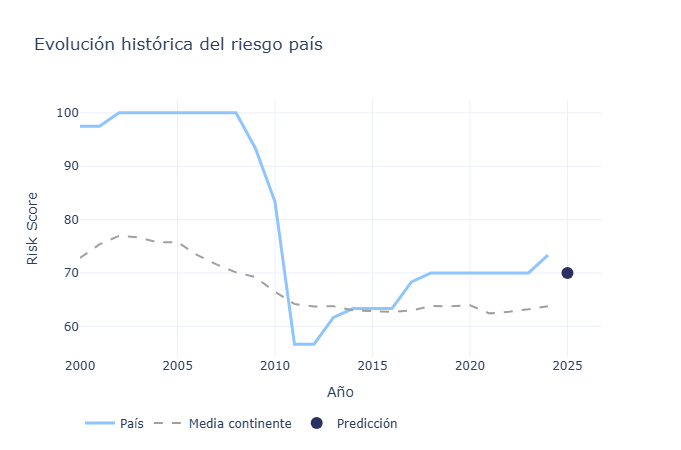

In [301]:
fig = plot_prediction_evolution(
    panel_B,
    "ESP",
    70
)


fig.show()

In [310]:
from IPython.display import HTML, display


def agency_rating_card_html(
    sp_rating,
    moodys_rating,
    fitch_rating
):

    sp_rating = sp_rating if pd.notna(sp_rating) else "."
    moodys_rating = moodys_rating if pd.notna(moodys_rating) else "."
    fitch_rating = fitch_rating if pd.notna(fitch_rating) else "."

    return f"""
    <div style="
        background:#FFFFFF;
        border:1px solid #D7E3F0;
        border-radius:16px;
        padding:24px;
        height:220px;
        box-sizing:border-box;
    ">

        <div style="
            font-size:17px;
            color:#1E293B;
            margin-bottom:30px;
        ">
            🏦 Calificaciones de las agencias
        </div>

        <div style="
            display:flex;
            justify-content:space-around;
            text-align:center;
        ">

            <div>
                <div style="
                    font-size:14px;
                    color:#64748B;
                ">
                    S&P
                </div>

                <div style="
                    font-size:32px;
                    font-weight:700;
                    color:#1E293B;
                    margin-top:8px;
                ">
                    {sp_rating}
                </div>
            </div>

            <div>
                <div style="
                    font-size:14px;
                    color:#64748B;
                ">
                    Moody's
                </div>

                <div style="
                    font-size:32px;
                    font-weight:700;
                    color:#1E293B;
                    margin-top:8px;
                ">
                    {moodys_rating}
                </div>
            </div>

            <div>
                <div style="
                    font-size:14px;
                    color:#64748B;
                ">
                    Fitch
                </div>

                <div style="
                    font-size:32px;
                    font-weight:700;
                    color:#1E293B;
                    margin-top:8px;
                ">
                    {fitch_rating}
                </div>
            </div>

        </div>

    </div>
    """

In [311]:
def score_to_rating(score):

    if pd.isna(score):
        return "—"

    if score >= 97.5:
        return "AAA"
    elif score >= 92.5:
        return "AA+"
    elif score >= 87.5:
        return "AA"
    elif score >= 82.5:
        return "AA-"
    elif score >= 77.5:
        return "A+"
    elif score >= 72.5:
        return "A"
    elif score >= 67.5:
        return "A-"
    elif score >= 62.5:
        return "BBB+"
    elif score >= 57.5:
        return "BBB"
    elif score >= 52.5:
        return "BBB-"
    elif score >= 47.5:
        return "BB+"
    elif score >= 42.5:
        return "BB"
    elif score >= 37.5:
        return "BB-"
    elif score >= 32.5:
        return "B+"
    elif score >= 27.5:
        return "B"
    elif score >= 22.5:
        return "B-"
    elif score >= 17.5:
        return "CCC+"
    elif score >= 12.5:
        return "CCC"
    elif score >= 7.5:
        return "CCC-"
    elif score >= 2.5:
        return "CC"
    else:
        return "C"

In [312]:
def agency_rating_card(
    country_data
):

    moodys = score_to_rating(
        country_data["moodys_score_t1"]
    )

    sp = score_to_rating(
        country_data["sp_score_t1"]
    )

    fitch = score_to_rating(
        country_data["fitch_score_t1"]
    )


    st.html(
        f"""
        <div style="
            background:white;
            border:1px solid #D7E3F0;
            border-radius:16px;
            padding:24px;
            height:220px;
        ">

        <div style="
            font-size:18px;
            color:#1E293B;
            margin-bottom:20px;
        ">
        🏦 Calificación actual de agencias
        </div>


        <div style="
            display:flex;
            justify-content:space-around;
            text-align:center;
        ">

            <div>
                <div style="color:#2563EB">
                S&P
                </div>
                <div style="
                font-size:32px;
                font-weight:700;
                ">
                {sp}
                </div>
            </div>


            <div>
                <div style="color:#F97316">
                Moody's
                </div>
                <div style="
                font-size:32px;
                font-weight:700;
                ">
                {moodys}
                </div>
            </div>


            <div>
                <div style="color:#16A34A">
                Fitch
                </div>
                <div style="
                font-size:32px;
                font-weight:700;
                ">
                {fitch}
                </div>
            </div>

        </div>

        </div>
        """
    )

In [313]:
def interpretation_card_html(
    prediction,
    current_rating
):

    change = prediction - current_rating

    if change > 3:
        icon = "🟢"
        title = "Mejora esperada"
        text = (
            "El modelo estima una mejora del perfil "
            "crediticio respecto a la situación actual."
        )

    elif change < -3:
        icon = "🔴"
        title = "Deterioro esperado"
        text = (
            "El modelo anticipa un deterioro del perfil "
            "crediticio respecto a la situación actual."
        )

    else:
        icon = "🟡"
        title = "Estabilidad esperada"
        text = (
            "El modelo estima una situación relativamente "
            "estable respecto al rating actual."
        )

    return f"""
    <div style="
        background:#F0F9F4;
        border:1px solid #B7E4C7;
        border-radius:16px;
        padding:24px;
        height:220px;
        box-sizing:border-box;
    ">

        <div style="
            font-size:17px;
            color:#1E293B;
            margin-bottom:25px;
        ">
            💡 Interpretación rápida
        </div>

        <div style="
            font-size:16px;
            font-weight:600;
            color:#334155;
            margin-bottom:12px;
        ">
            {icon} {title}
        </div>

        <div style="
            font-size:14px;
            line-height:1.55;
            color:#64748B;
        ">
            {text}
        </div>

        <div style="
            margin-top:15px;
            font-size:14px;
            color:#475569;
        ">
            Variación estimada:
            <b>{change:+.1f} puntos</b>
        </div>

    </div>
    """

In [314]:
def model_info_card_html(
    n_features
):

    return f"""
    <div style="
        background:#F8FAFC;
        border:1px solid #DCE4ED;
        border-radius:16px;
        padding:20px 24px;
        margin-top:18px;
        box-sizing:border-box;
    ">

        <div style="
            font-size:16px;
            color:#1E293B;
            margin-bottom:14px;
        ">
            📌 Sobre la predicción
        </div>

        <div style="
            display:flex;
            gap:45px;
            flex-wrap:wrap;
            font-size:14px;
            color:#64748B;
        ">

            <div>
                Modelo<br>
                <b style="color:#334155;">
                    Random Forest
                </b>
            </div>

            <div>
                Variables fundamentales<br>
                <b style="color:#334155;">
                    {n_features}
                </b>
            </div>

            <div>
                Horizonte<br>
                <b style="color:#334155;">
                    Rating t+1
                </b>
            </div>

            <div>
                MAE test<br>
                <b style="color:#334155;">
                    4.988 puntos
                </b>
            </div>

            <div>
                R² test<br>
                <b style="color:#334155;">
                    0.928
                </b>
            </div>

        </div>

    </div>
    """

In [315]:
sp_rating = "BBB-"
moodys_rating = "Baa3"
fitch_rating = "BBB-"

prediction = 54.0
current_rating = 48.0


html = f"""
<div style="
    display:flex;
    gap:18px;
    width:900px;
">

    <div style="flex:1;">
        {agency_rating_card_html(
            sp_rating,
            moodys_rating,
            fitch_rating
        )}
    </div>

    <div style="flex:1;">
        {interpretation_card_html(
            prediction,
            current_rating
        )}
    </div>

</div>

<div style="width:900px;">
    {model_info_card_html(
        len(features)
    )}
</div>
"""


display(
    HTML(html)
)

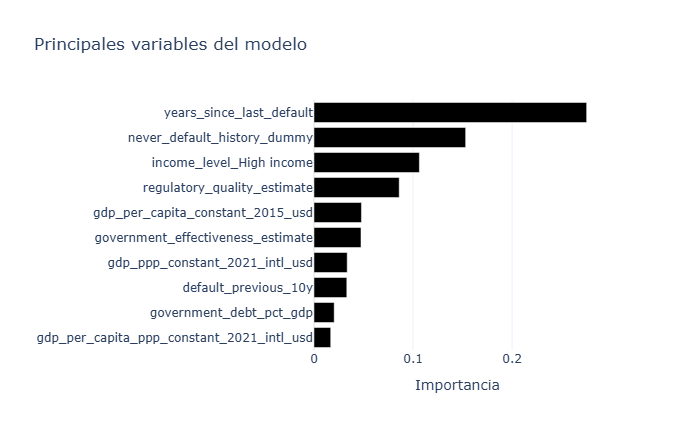

In [316]:
import pandas as pd
import plotly.express as px

importance_df = pd.DataFrame({
    "variable": model_package["feature_names"],
    "importance": model.feature_importances_
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .head(10)
    .sort_values(
        "importance"
    )
)

fig_importance = px.bar(
    importance_df,
    x="importance",
    y="variable",
    orientation="h",
    title="Principales variables del modelo"
)

fig_importance.update_layout(
    template="plotly_white",
    height=430,
    xaxis_title="Importancia",
    yaxis_title="",
    showlegend=False
)

fig_importance.show()

In [322]:
def similar_countries_card_html(
    countries
):

    countries_html = ""

    for country, prediction in countries:

        rating = score_to_rating(
            prediction
        )

        countries_html += f"""
        <div style="
            padding:11px 0;
            border-bottom:1px solid #E2E8F0;
            display:flex;
            justify-content:space-between;
            align-items:center;
        ">

            <div style="
                font-size:15px;
                color:#334155;
            ">
                🌍 {country}
            </div>

            <div style="
                text-align:right;
            ">

                <div style="
                    font-size:17px;
                    font-weight:600;
                    color:#1E293B;
                ">
                    {prediction:.1f}
                    <span style="
                        font-size:12px;
                        font-weight:400;
                        color:#64748B;
                    ">
                        /100
                    </span>
                </div>

                <div style="
                    font-size:12px;
                    color:#64748B;
                    margin-top:2px;
                ">
                    {rating}
                </div>

            </div>

        </div>
        """

    return f"""
    <div style="
        background:#FFFFFF;
        border:1px solid #D7E3F0;
        border-radius:16px;
        padding:24px;
        height:260px;
        box-sizing:border-box;
    ">

        <div style="
            font-size:17px;
            color:#1E293B;
            margin-bottom:12px;
        ">
            🧩 Países con perfil similar
        </div>

        {countries_html}

    </div>
    """

In [323]:
similar_countries = [
    ("Portugal", 67.4),
    ("Italy", 61.8),
    ("France", 78.2)
]

In [319]:
def strengths_weaknesses_card_html(
    strengths,
    weaknesses
):

    strengths_html = ""

    for item in strengths:

        strengths_html += f"""
        <div style="
            margin-bottom:8px;
            font-size:14px;
            color:#334155;
        ">
            ✓ {item}
        </div>
        """


    weaknesses_html = ""

    for item in weaknesses:

        weaknesses_html += f"""
        <div style="
            margin-bottom:8px;
            font-size:14px;
            color:#334155;
        ">
            • {item}
        </div>
        """


    return f"""
    <div style="
        background:#FFFFFF;
        border:1px solid #D7E3F0;
        border-radius:16px;
        padding:24px;
        height:260px;
        box-sizing:border-box;
    ">

        <div style="
            font-size:17px;
            color:#1E293B;
            margin-bottom:18px;
        ">
            🔎 Perfil del país
        </div>


        <div style="
            display:flex;
            gap:40px;
        ">

            <div style="flex:1;">

                <div style="
                    color:#16A34A;
                    font-weight:600;
                    margin-bottom:10px;
                ">
                    🟢 Fortalezas
                </div>

                {strengths_html}

            </div>


            <div style="flex:1;">

                <div style="
                    color:#DC2626;
                    font-weight:600;
                    margin-bottom:10px;
                ">
                    🔴 Debilidades
                </div>

                {weaknesses_html}

            </div>

        </div>

    </div>
    """

In [320]:
strengths = [
    "Alta calidad institucional",
    "Historial crediticio favorable"
]

weaknesses = [
    "Deuda pública elevada",
    "Saldo fiscal reducido"
]

In [324]:
html = f"""
<div style="
    display:flex;
    gap:18px;
    width:900px;
">

    <div style="flex:0.8;">
        {similar_countries_card_html(
            similar_countries
        )}
    </div>

    <div style="flex:1.7;">
        {strengths_weaknesses_card_html(
            strengths,
            weaknesses
        )}
    </div>

</div>
"""

display(
    HTML(html)
)

In [325]:
from utils.prediction import load_prediction_data

prediction_data = load_prediction_data()

print(
    prediction_data.keys()
)

print(
    prediction_data["panel"].shape
)

dict_keys(['model', 'preprocessor', 'features', 'feature_names', 'panel', 'agency_ratings'])
(3434, 108)


In [329]:
import importlib
import inspect
import utils.clustering

importlib.reload(
    utils.clustering
)

print(
    inspect.getsource(
        utils.clustering.plot_cluster_sizes
    )
)

def plot_cluster_sizes(
    summary,
    color_map
):

    fig = go.Figure()

    for _, row in (
        summary.iterrows()
    ):

        cluster = int(
            row["Cluster"]
        )

        label = (
            f"Clúster {cluster} · "
            f"{row['Perfil de riesgo']}"
        )

        fig.add_trace(
            go.Bar(
                x=[
                    row["Países"]
                ],
                y=[
                    label
                ],
                orientation="h",
                marker_color=
                    color_map[
                        cluster
                    ],
                text=[
                    int(
                        row["Países"]
                    )
                ],
                textposition=
                    "outside",
                showlegend=False
            )
        )

    fig.update_layout(
        title="Tamaño de los clústeres",
        xaxis_title="Número de países",
        yaxis_title=

In [327]:
import importlib
import utils.prediction

importlib.reload(
    utils.prediction
)

from utils.prediction import get_similar_countries

print(
    "Función cargada correctamente"
)

Función cargada correctamente


In [1]:
from utils.data_indicators import (
    get_data_countries,
    get_data_years,
    get_key_indicators,
    get_indicator_table,
    get_indicator_options,
    plot_indicator_evolution,
    get_country_download_data
)

print("Datos e indicadores cargado correctamente")

Datos e indicadores cargado correctamente


In [7]:
import utils.alerts

print(
    utils.alerts.__file__
)

print(
    hasattr(
        utils.alerts,
        "get_country_alerts"
    )
)

C:\Users\pedro.lopez\Desktop\MASTER\TFM\utils\alerts.py
True


In [8]:
from utils.full_report import (
    create_full_country_report,
    get_cluster_report_info
)

print(
    "Generador de informes cargado correctamente"
)

Generador de informes cargado correctamente
